# Trades Full C+D

Notebook especifico para auditar el `current` final mergeado `C + D` de `trades`.

Este notebook no reutiliza ni modifica el flujo de `D`: replica la auditoria full sobre el parquet final consolidado `trades_current_cd_merged/trades_current.parquet`.


## Full data set `trades_current_cd_merged`

Replica del bloque full de `trades`, pero apuntando al `current` final `C + D`.

Ajustes respecto a `D`:
- se trabaja en modo `current-only`
- la fuente es `trades_current_cd_merged/trades_current.parquet`
- si no existe estructura de batches del run de validacion, el bloque de drift debe degradar con gracia


In [1]:
import gc
import json
import runpy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SCRIPT_40 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/40_cd_run_snapshot.py")
RUN_DIR_CD = Path("C:/TSIS_Data/02_backtest_SmallCaps/runs/backtest/trades_v2_materialized/trades_current_cd_merged")
CURRENT_PARQUET_CD = RUN_DIR_CD / "trades_current.parquet"
CACHE_DIR_CD = RUN_DIR_CD / "root_cause_exports" / "notebook_cd_cache"
MANIFEST_PATH_CD = CACHE_DIR_CD / "manifest.json"
BUILD_CMD_CD = (
    "python C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/"
    "build_trades_cd_audit_artifacts.py"
)

mod40 = runpy.run_path(str(SCRIPT_40))
mod40["configure_cd_notebook_style"]()

if not MANIFEST_PATH_CD.exists():
    raise FileNotFoundError(
        f"No existe {MANIFEST_PATH_CD}. Ejecuta primero: {BUILD_CMD_CD}"
    )

manifest_cd = json.loads(MANIFEST_PATH_CD.read_text(encoding="utf-8"))
row_count_cd = int(manifest_cd.get("row_count", 0))


def load_cache(name: str) -> pd.DataFrame:
    path = CACHE_DIR_CD / f"{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Falta cache: {path}")
    return pd.read_parquet(path)


def load_text(name: str) -> str:
    path = CACHE_DIR_CD / name
    if not path.exists():
        raise FileNotFoundError(f"Falta texto: {path}")
    return path.read_text(encoding="utf-8")


def load_break_cache():
    return load_cache("daily_break_cd")


def load_band_cache():
    return load_cache("band_df_cd")


def load_tax_cache():
    return load_cache("tax_df_cd")


def release_df(*names):
    for name in names:
        if name in globals():
            del globals()[name]
    plt.close('all')
    gc.collect()


display(
    Markdown(
        f"**full rows:** {row_count_cd:,}  \n"
        f"**current parquet:** `{CURRENT_PARQUET_CD}`  \n"
        f"**cache dir:** `{CACHE_DIR_CD}`  \n"
        f"**generated_at_utc:** `{manifest_cd.get('generated_at_utc')}`  \n"
        f"**batch_size:** `{manifest_cd.get('batch_size')}`  \n"
        f"**max_batches:** `{manifest_cd.get('max_batches')}`"
    )
)

TABLE_ROWS_DEFAULT = 20
TABLE_ROWS = {
    "snapshot_cd": 20,
    "severity_counts_cd": 20,
    "batch_rate_roll50_cd": 20,
    "hard_issue_counts_cd": 20,
    "warn_counts_cd": 20,
    "issue_evidence_cd": 20,
    "ticker_focus_full": 20,
    "dup_outlier_view": 20,
    "issue_examples_full": 20,
    "warn_examples_full": 20,
    "exec_summary_full": 20,
    "break_summary_cd": 20,
    "top_breaks": 50,
    "break_extreme_view": 30,
    "summary_breaks": 20,
    "abs_bucket_counts": 20,
    "pct_bucket_counts": 20,
    "cross_abs": 20,
    "cross_pct": 20,
    "cross_abs_pct": 20,
    "cross_pct_pct": 20,
    "taxonomy_summary": 20,
    "taxonomy_side_view": 20,
    "final_summary": 20,
    "abs_signal": 20,
    "pct_signal": 20,
    "side_signal": 20,
    "side_signal_view": 20,
}


def get_table_rows(name: str, default: int | None = None) -> int:
    if default is None:
        default = TABLE_ROWS_DEFAULT
    return int(TABLE_ROWS.get(name, default))


def display_table(obj, name: str, default: int | None = None, tail: bool = False):
    rows = get_table_rows(name, default)
    if hasattr(obj, "head") and hasattr(obj, "tail"):
        preview = obj.tail(rows) if tail else obj.head(rows)
        display(preview)
    else:
        display(obj)


**full rows:** 9,632,124  
**current parquet:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\trades_current.parquet`  
**cache dir:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\root_cause_exports\notebook_cd_cache`  
**generated_at_utc:** `2026-04-12T11:00:56.907715+00:00`  
**batch_size:** `10000`  
**max_batches:** `None`

### 1. Snapshot ejecutivo

Primero se comprueba el reparto real de severidades del merge final `C + D` y si el materializado conserva alguna senal util de drift por batch.


,0
source,trades_current_cd_merged
current_parquet,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\trades_current.parquet
current_rows,9632124
hard_fail,3685493
soft_fail,5392744
pass,553887
pass_rate_pct,5.75
hard_fail_rate_pct,38.263
soft_fail_rate_pct,55.987


,severity,files,pct
0,PASS,553887,5.750414
1,SOFT_FAIL,5392744,55.987070
2,HARD_FAIL,3685493,38.262516


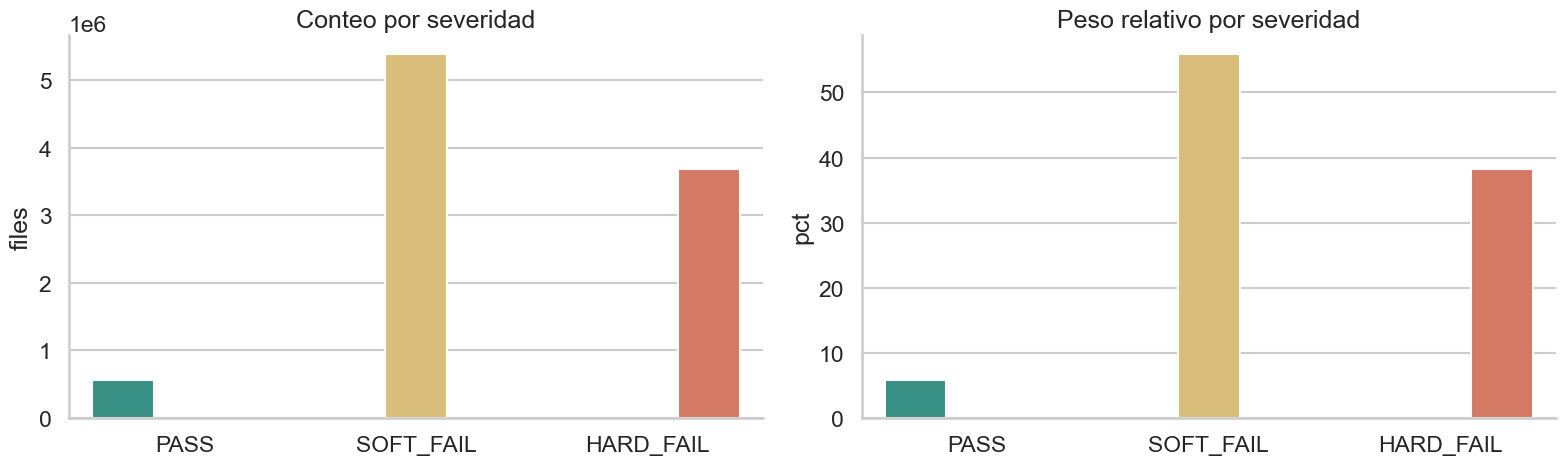

,PASS,SOFT_FAIL,HARD_FAIL
2386,7.120000,72.62400,20.256000
2387,6.932000,72.24800,20.820000
2388,7.272000,71.57600,21.152000
2389,7.324000,71.37200,21.304000
2390,7.188000,71.36000,21.452000
2391,7.228000,71.08400,21.688000
2392,7.264000,70.77200,21.964000
2393,7.264000,70.77200,21.964000
2394,7.264000,70.95600,21.780000
2395,6.920000,71.38400,21.696000


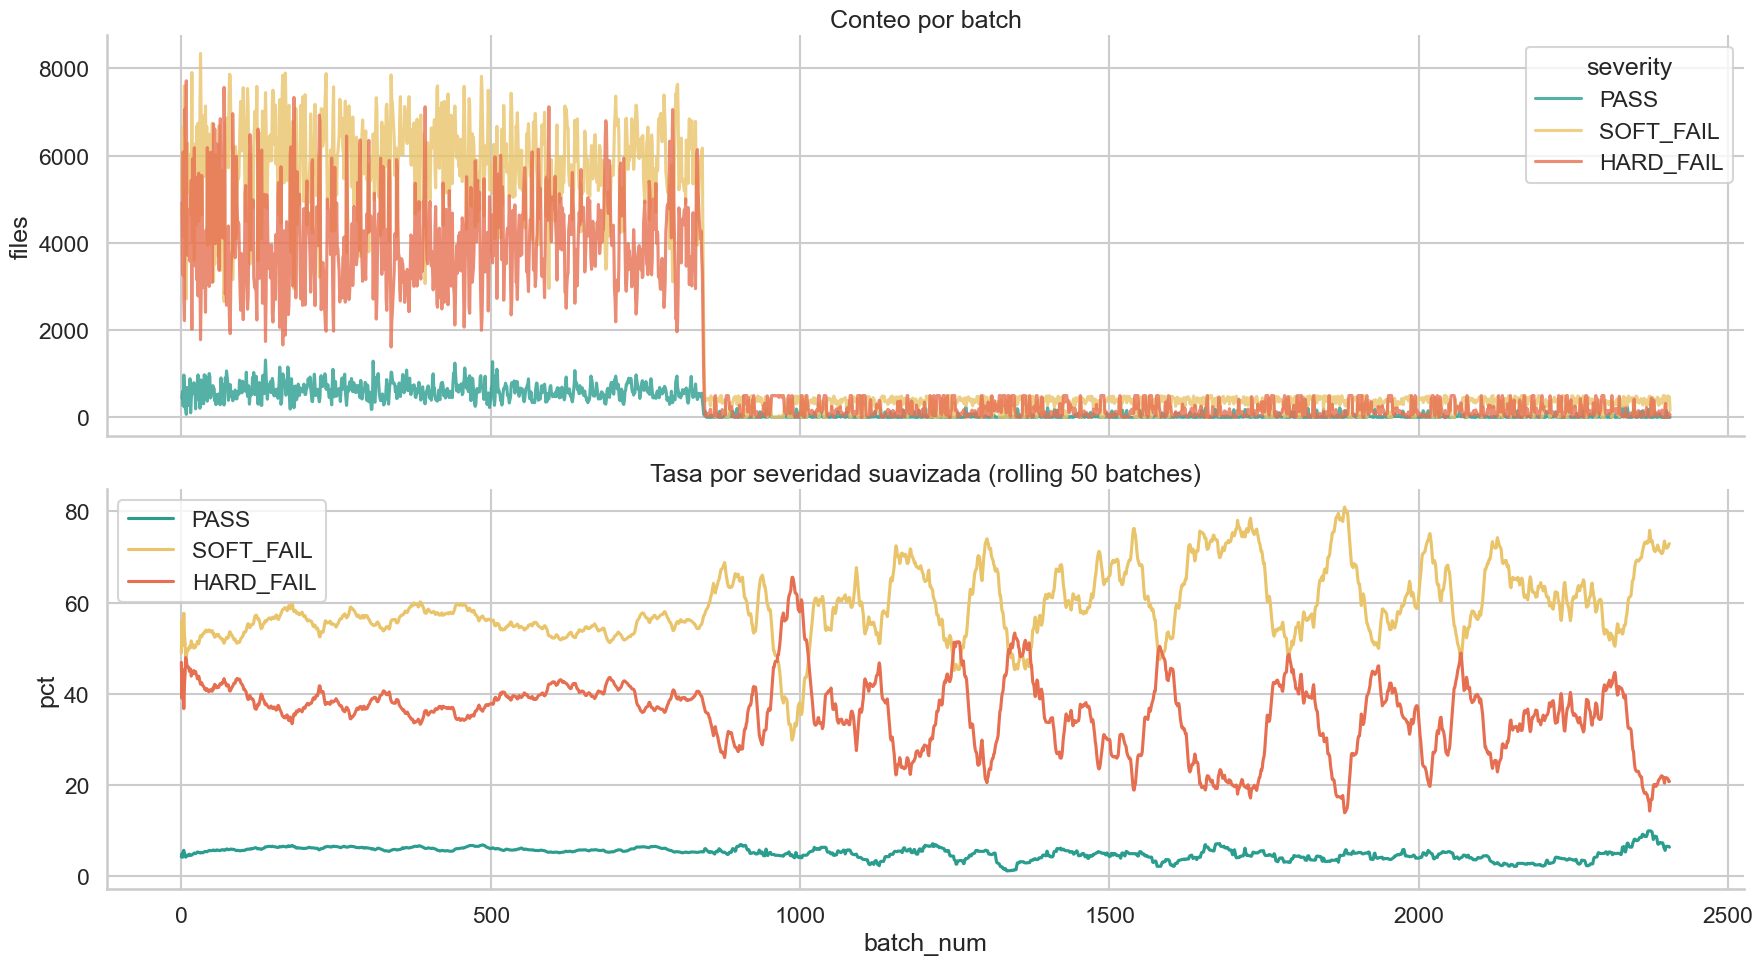

In [2]:
sev_counts_cd = load_cache("severity_counts_cd")
snapshot_cd = load_cache("snapshot_cd")
batch_mix_cd = load_cache("batch_mix_cd")
batch_rate_roll50_cd = load_cache("batch_rate_roll50_cd")

batch_pivot_cd = (
    batch_mix_cd.pivot(index="batch_num", columns="severity", values="files")
    .fillna(0)
    .sort_index()
    if not batch_mix_cd.empty else pd.DataFrame()
)

display_table(snapshot_cd.T, "snapshot_cd")
display_table(sev_counts_cd, "severity_counts_cd")
mod40["plot_cd_severity_snapshot"](sev_counts_cd)
display_table(batch_rate_roll50_cd, "batch_rate_roll50_cd", tail=True)
mod40["plot_cd_batch_snapshot"](batch_pivot_cd, batch_rate_roll50_cd)


### 2. Raiz de los HARD_FAIL y de los warnings

Aqui interesa la descomposicion atomica del merge final `C + D`, manteniendo el mismo parser fiable de `issues`, `warns` y `metrics`.


,issue,files
0,trade_price_outside_daily_range,2983713
1,duplicate_excess_ratio_gt_hard_cap,831782
2,negative_or_zero_size_rows,167606
3,negative_or_zero_price_rows,2328


,warn,files
0,trade_price_outside_1m_range,5094621
1,duplicate_exact_trade_rows_present,4224703
2,off_session_trades_present,3191518
3,duplicate_excess_ratio_gt_threshold,1686525
4,rows_lt_10,625824
5,possible_corporate_action_scale_mismatch_vs_1m,355445
6,possible_corporate_action_scale_mismatch_vs_daily,235235
7,missing_ohlcv_1m_reference,158609
8,missing_ohlcv_daily_reference,148186
9,possible_corporate_action_scale_mismatch,120808


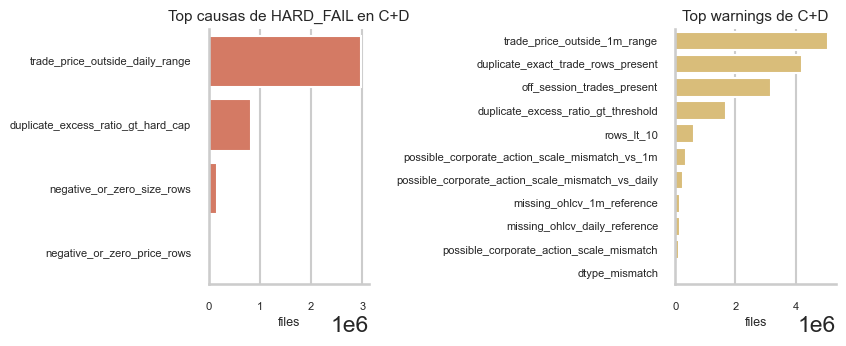

,issue,files,tickers,dates,has_1m_warn_pct,median_off_session_pct,median_dup_pct,median_vol_vs_daily,median_vol_vs_1m
0,trade_price_outside_daily_range,2983713,4995,5325,98.142583,0.0,0.450450,4.678692,4.985134
1,duplicate_excess_ratio_gt_hard_cap,831782,3182,4535,33.100139,0.0,14.285714,1.007439,1.032195
2,negative_or_zero_size_rows,167606,3527,619,36.964070,0.0,1.168465,1.000000,1.003577
3,negative_or_zero_price_rows,2328,79,798,17.525773,0.0,0.000000,1.000000,1.000009


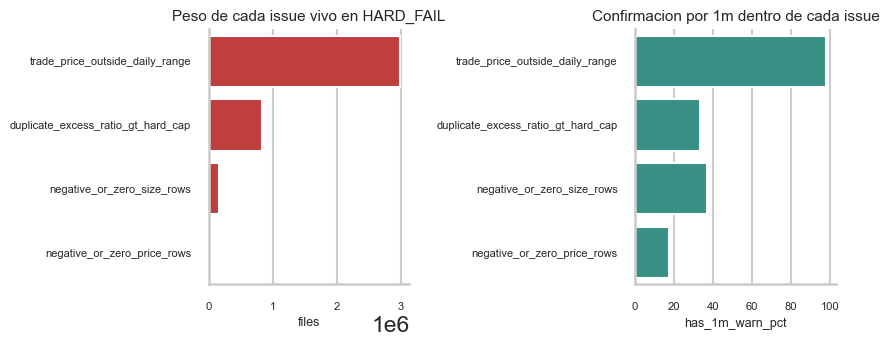

In [3]:
SCRIPT_41 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/41_cd_root_cause_overview.py")
mod41 = runpy.run_path(str(SCRIPT_41))

hard_issue_counts_cd = load_cache("hard_issue_counts_cd")
warn_counts_cd = load_cache("warn_counts_cd")
issue_evidence_cd = load_cache("issue_evidence_cd")

hard_issue_counts_full = hard_issue_counts_cd
warn_counts_full = warn_counts_cd
issue_evidence_full = issue_evidence_cd

display_table(hard_issue_counts_cd, "hard_issue_counts_cd")
display_table(warn_counts_cd, "warn_counts_cd")
mod41["plot_root_cause_counts_cd"](hard_issue_counts_cd, warn_counts_cd, top_n=15)
display_table(issue_evidence_cd, "issue_evidence_cd")
mod41["plot_issue_evidence_cd"](issue_evidence_cd)


### 3. Donde se concentran los problemas

En full interesa mas la escala temporal agregada y la concentracion por ticker.


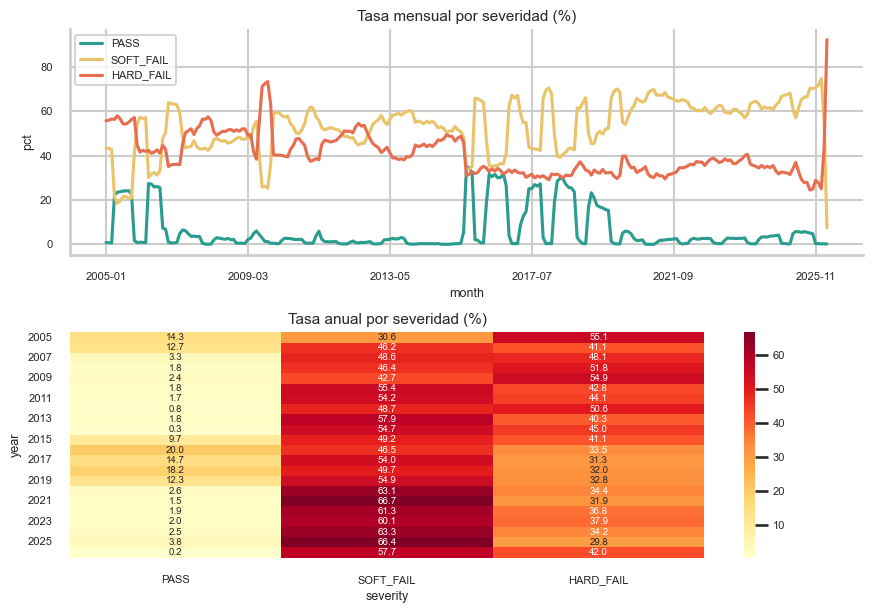

,ticker,HARD_FAIL,PASS,SOFT_FAIL,total,hard_fail_rate_pct
0,SCON,3941.0,0.0,0.0,3941.0,100.0
1,ABIO,3923.0,0.0,0.0,3923.0,100.0
2,SNSS,3853.0,0.0,0.0,3853.0,100.0
3,VICL,3689.0,0.0,0.0,3689.0,100.0
4,GTXI,3630.0,0.0,0.0,3630.0,100.0
5,THLD,3124.0,0.0,0.0,3124.0,100.0
6,MESA,3100.0,0.0,0.0,3100.0,100.0
7,DAC,3072.0,0.0,0.0,3072.0,100.0
8,PTI,2935.0,0.0,0.0,2935.0,100.0
9,GLYC,2872.0,0.0,0.0,2872.0,100.0


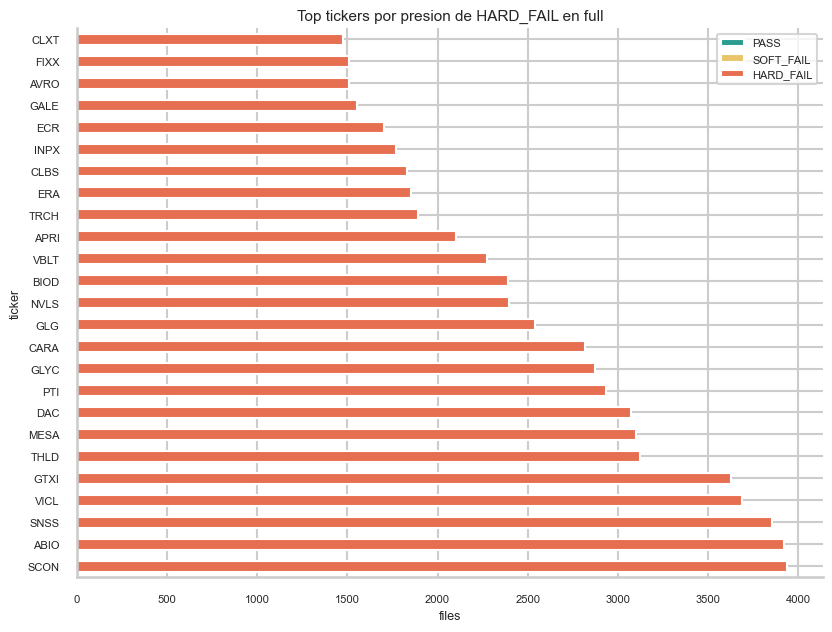

In [4]:
SCRIPT_42 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/42_cd_problem_concentration.py")
mod42 = runpy.run_path(str(SCRIPT_42))

month_rate_full = load_cache("time_concentration_month_rate_cd").set_index("month")
year_rate_full = load_cache("time_concentration_year_rate_cd").set_index("year")
ticker_focus_full = load_cache("ticker_focus_cd")

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

with plt.rc_context(plot_rc):
    mod42["plot_time_concentration_full"](month_rate_full, year_rate_full)
display_table(ticker_focus_full, "ticker_focus_full")
with plt.rc_context(plot_rc):
    mod42["plot_ticker_focus_full"](ticker_focus_full.set_index("ticker"))


### 4. Diagnostico quirurgico de causas especificas

Se replica la vista de smoke, pero muestreando para que los graficos sigan siendo manejables.


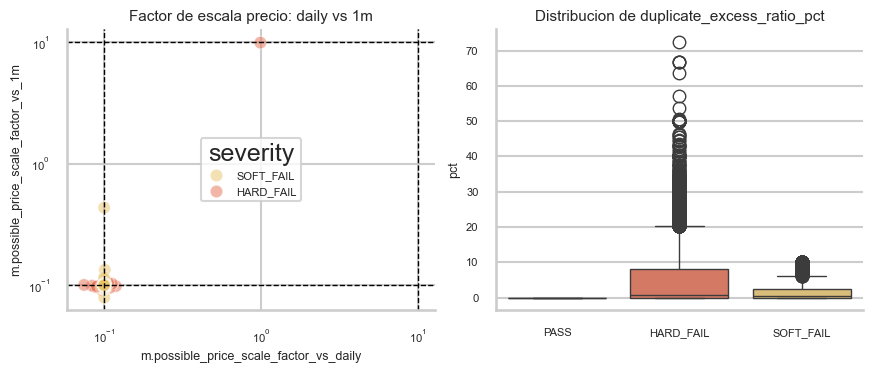

,ticker,date,severity,m.duplicate_excess_ratio_pct,m.max_trades_same_timestamp,file
0,ACB,2008-03-05,HARD_FAIL,72.413793,6,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\ACB\year=2008\month=03\day=2008-03-05\market.parquet
1,SSY,2006-09-25,HARD_FAIL,66.666667,7,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\SSY\year=2006\month=09\day=2006-09-25\market.parquet
2,KINS,2012-01-30,HARD_FAIL,66.666667,6,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\KINS\year=2012\month=01\day=2012-01-30\market.parquet
3,IPDN,2014-11-28,HARD_FAIL,66.666667,3,D:\trades_ticks_prod_2005_2026\IPDN\year=2014\month=11\day=2014-11-28\market.parquet
4,III,2012-06-20,HARD_FAIL,63.741339,18,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\III\year=2012\month=06\day=2012-06-20\market.parquet
5,CTP,2013-08-12,HARD_FAIL,57.142857,6,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\CTP\year=2013\month=08\day=2013-08-12\market.parquet
6,OTEL,2015-06-10,HARD_FAIL,53.608247,13,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\OTEL\year=2015\month=06\day=2015-06-10\market.parquet
7,ARTW,2012-01-20,HARD_FAIL,50.561798,15,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\ARTW\year=2012\month=01\day=2012-01-20\market.parquet
8,ATLO,2007-11-07,HARD_FAIL,50.000000,4,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\ATLO\year=2007\month=11\day=2007-11-07\market.parquet
9,SENEB,2011-05-16,HARD_FAIL,50.000000,3,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\SENEB\year=2011\month=05\day=2011-05-16\market.parquet


In [5]:
SCRIPT_43 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/43_cd_quirurgical_diagnostics.py")
mod43 = runpy.run_path(str(SCRIPT_43))

scale_df_full = load_cache("diag_scale_cd")
dup_df_full = load_cache("diag_dup_cd")
dup_outlier_view = load_cache("diag_dup_outlier_view_cd")

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

with plt.rc_context(plot_rc):
    mod43["plot_scale_and_dup_diagnostics"](scale_df_full, dup_df_full)
display_table(dup_outlier_view, "dup_outlier_view")

release_df("scale_df_full", "dup_df_full", "dup_outlier_view")


### 5. Drill-down final: ejemplos concretos

Se dejan ejemplos representativos del issue duro dominante y del warning dominante.


In [6]:
FOCUS_ISSUE_FULL = manifest_cd.get("focus_issue")
FOCUS_WARN_FULL = manifest_cd.get("focus_warn")
issue_examples_full = load_cache("issue_examples_cd")
warn_examples_full = load_cache("warn_examples_cd")

display(Markdown(f"**FOCUS_ISSUE_FULL:** `{FOCUS_ISSUE_FULL}`"))
display_table(issue_examples_full, "issue_examples_full")
display(Markdown(f"**FOCUS_WARN_FULL:** `{FOCUS_WARN_FULL}`"))
display_table(warn_examples_full, "warn_examples_full")


**FOCUS_ISSUE_FULL:** `trade_price_outside_daily_range`

,ticker,date,severity,batch_id,file,m.price_min,m.price_max,m.trade_vwap,m.vw,m.ohlcv_1m_low_min,m.ohlcv_1m_high_max,m.trade_volume_vs_daily_ratio,m.trade_volume_vs_1m_ratio,m.possible_price_scale_factor_vs_daily,m.possible_price_scale_factor_vs_1m,issues_list,warns_list
0,AABA,2017-10-16,HARD_FAIL,batch_000001,D:\trades_ticks_prod_2005_2026\AABA\year=2017\month=10\day=2017-10-16\market.parquet,66.0000,68.1300,67.822969,67.8543,67.3600,68.1800,0.857575,1.003412,0.999538,0.999993,[trade_price_outside_daily_range],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"
1,AAMC,2014-08-12,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2014\month=08\day=2014-08-12\market.parquet,557.0000,605.0000,565.487916,332.3195,327.6471,341.1765,0.534936,0.774301,1.701639,1.702813,[trade_price_outside_daily_range],"[duplicate_excess_ratio_gt_threshold, trade_price_outside_1m_range]"
2,AAMC,2014-12-16,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2014\month=12\day=2014-12-16\market.parquet,422.1400,450.0000,437.526557,257.4133,253.5294,264.7059,0.543966,0.712359,1.699705,1.694975,[trade_price_outside_daily_range],"[duplicate_excess_ratio_gt_threshold, off_session_trades_present, trade_price_outside_1m_range]"
3,AAMC,2016-01-27,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2016\month=01\day=2016-01-27\market.parquet,15.2000,17.3989,16.062369,9.4482,8.9412,10.2346,0.588204,0.594772,1.700045,1.682869,[trade_price_outside_daily_range],"[off_session_trades_present, trade_price_outside_1m_range]"
4,AAMC,2016-10-06,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2016\month=10\day=2016-10-06\market.parquet,20.2130,22.7600,22.049174,12.9906,11.8900,13.3882,0.530734,0.628350,1.697318,1.710970,[trade_price_outside_daily_range],[trade_price_outside_1m_range]
5,AAMC,2017-06-13,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2017\month=06\day=2017-06-13\market.parquet,82.3509,87.9500,85.246445,50.5668,49.5294,52.0294,0.491597,0.592520,1.685818,1.664438,[trade_price_outside_daily_range],[trade_price_outside_1m_range]
6,AAMC,2018-06-14,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2018\month=06\day=2018-06-14\market.parquet,64.0000,70.1000,68.750378,39.7746,39.7794,41.2353,0.588235,1.071236,1.728500,1.697232,[trade_price_outside_daily_range],[trade_price_outside_1m_range]
7,AAME,2020-10-07,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAME\year=2020\month=10\day=2020-10-07\market.parquet,1.9700,2.0716,1.997947,1.9981,1.9700,2.0000,1.003731,2.002481,0.999923,1.003993,[trade_price_outside_daily_range],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"
8,AAME,2022-02-23,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAME\year=2022\month=02\day=2022-02-23\market.parquet,2.4600,2.7000,2.573931,2.5722,2.5000,2.6500,1.011745,1.049872,1.000673,0.992922,[trade_price_outside_daily_range],"[duplicate_exact_trade_rows_present, off_session_trades_present, trade_price_outside_1m_range]"
9,AAME,2023-11-24,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAME\year=2023\month=11\day=2023-11-24\market.parquet,1.8900,1.9300,1.920131,1.9214,1.9105,1.9300,0.994394,1.914980,0.999339,0.998993,[trade_price_outside_daily_range],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"


**FOCUS_WARN_FULL:** `trade_price_outside_1m_range`

,ticker,date,severity,batch_id,file,m.duplicate_excess_ratio_pct,m.max_trades_same_timestamp,m.off_session_trade_pct,m.trade_volume_vs_daily_ratio,m.trade_volume_vs_1m_ratio,issues_list,warns_list
0,AABA,2018-07-20,SOFT_FAIL,batch_000001,D:\trades_ticks_prod_2005_2026\AABA\year=2018\month=07\day=2018-07-20\market.parquet,0.017080,3,0.000000,0.754279,1.010122,[],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"
1,AAIC,2022-02-08,SOFT_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAIC\year=2022\month=02\day=2022-02-08\market.parquet,0.503778,2,17.380353,1.007841,1.031135,[],"[duplicate_exact_trade_rows_present, off_session_trades_present, trade_price_outside_1m_range]"
2,AAMC,2015-03-06,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2015\month=03\day=2015-03-06\market.parquet,5.000000,4,62.500000,0.438166,1.589916,[trade_price_outside_daily_range],"[duplicate_excess_ratio_gt_threshold, off_session_trades_present, trade_price_outside_1m_range]"
3,AAMC,2016-10-25,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2016\month=10\day=2016-10-25\market.parquet,0.000000,1,0.000000,0.579701,0.600656,[trade_price_outside_daily_range],[trade_price_outside_1m_range]
4,AAMC,2019-12-09,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2019\month=12\day=2019-12-09\market.parquet,0.000000,1,5.142857,0.595609,0.621907,[trade_price_outside_daily_range],"[off_session_trades_present, trade_price_outside_1m_range]"
5,AAME,2021-11-05,SOFT_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAME\year=2021\month=11\day=2021-11-05\market.parquet,0.840336,2,0.000000,1.010666,1.111817,[],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"
6,AAME,2023-04-11,HARD_FAIL,batch_000001,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAME\year=2023\month=04\day=2023-04-11\market.parquet,3.703704,2,0.000000,1.030573,1.465580,[trade_price_outside_daily_range],"[duplicate_excess_ratio_gt_threshold, trade_price_outside_1m_range]"
7,AAN,2016-02-17,SOFT_FAIL,batch_000002,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAN\year=2016\month=02\day=2016-02-17\market.parquet,0.072505,4,27.366471,0.960552,0.998433,[],"[duplicate_exact_trade_rows_present, off_session_trades_present, trade_price_outside_1m_range]"
8,AAN,2018-01-25,SOFT_FAIL,batch_000002,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAN\year=2018\month=01\day=2018-01-25\market.parquet,0.000000,1,25.241967,0.915403,0.997341,[],"[off_session_trades_present, trade_price_outside_1m_range]"
9,AAN,2020-08-04,SOFT_FAIL,batch_000002,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAN\year=2020\month=08\day=2020-08-04\market.parquet,1.018277,4,0.000000,0.875864,0.982091,[],"[duplicate_exact_trade_rows_present, trade_price_outside_1m_range]"


### 6. Lectura ejecutiva del full


In [7]:
exec_summary_full = load_cache("exec_summary_cd")
exec_readout_full_md = load_text("exec_readout_cd.md")
display_table(exec_summary_full.T, "exec_summary_full")
display(Markdown(exec_readout_full_md))


,0
selected_files,9632124
pass_rate_pct,5.75
soft_fail_rate_pct,55.987
hard_fail_rate_pct,38.263
top_hard_issue,trade_price_outside_daily_range
top_hard_issue_files,2983713
top_hard_issue_pct_of_hard,80.958
top_hard_issue_tickers,4995
top_hard_issue_dates,5325
top_hard_issue_has_1m_warn_pct,98.143


**Lectura rapida**

- El full tiene `PASS` residual y esta dominado por `SOFT_FAIL` + `HARD_FAIL`.
- El `HARD_FAIL` dominante es `trade_price_outside_daily_range` y explica la mayor parte del residuo duro.
- Ese issue no esta concentrado en pocos outliers: aparece en cientos de tickers y miles de fechas.
- La confirmacion por `1m` y los ratios de volumen sugieren que el residuo dominante es un problema real de referencia/escala, no ruido aislado.

Con la siguiente celdas puedes medir:

  - cuánto rompe por abajo
  - cuánto rompe por arriba
  - en absoluto
  - y relativo al rango diario


,0
files,2983713
tickers,4995
dates,5325
below_only,1891223
above_only,604899
both,487591


,files,tickers,dates,below_only,above_only,both
0,2983713,4995,5325,1891223,604899,487591


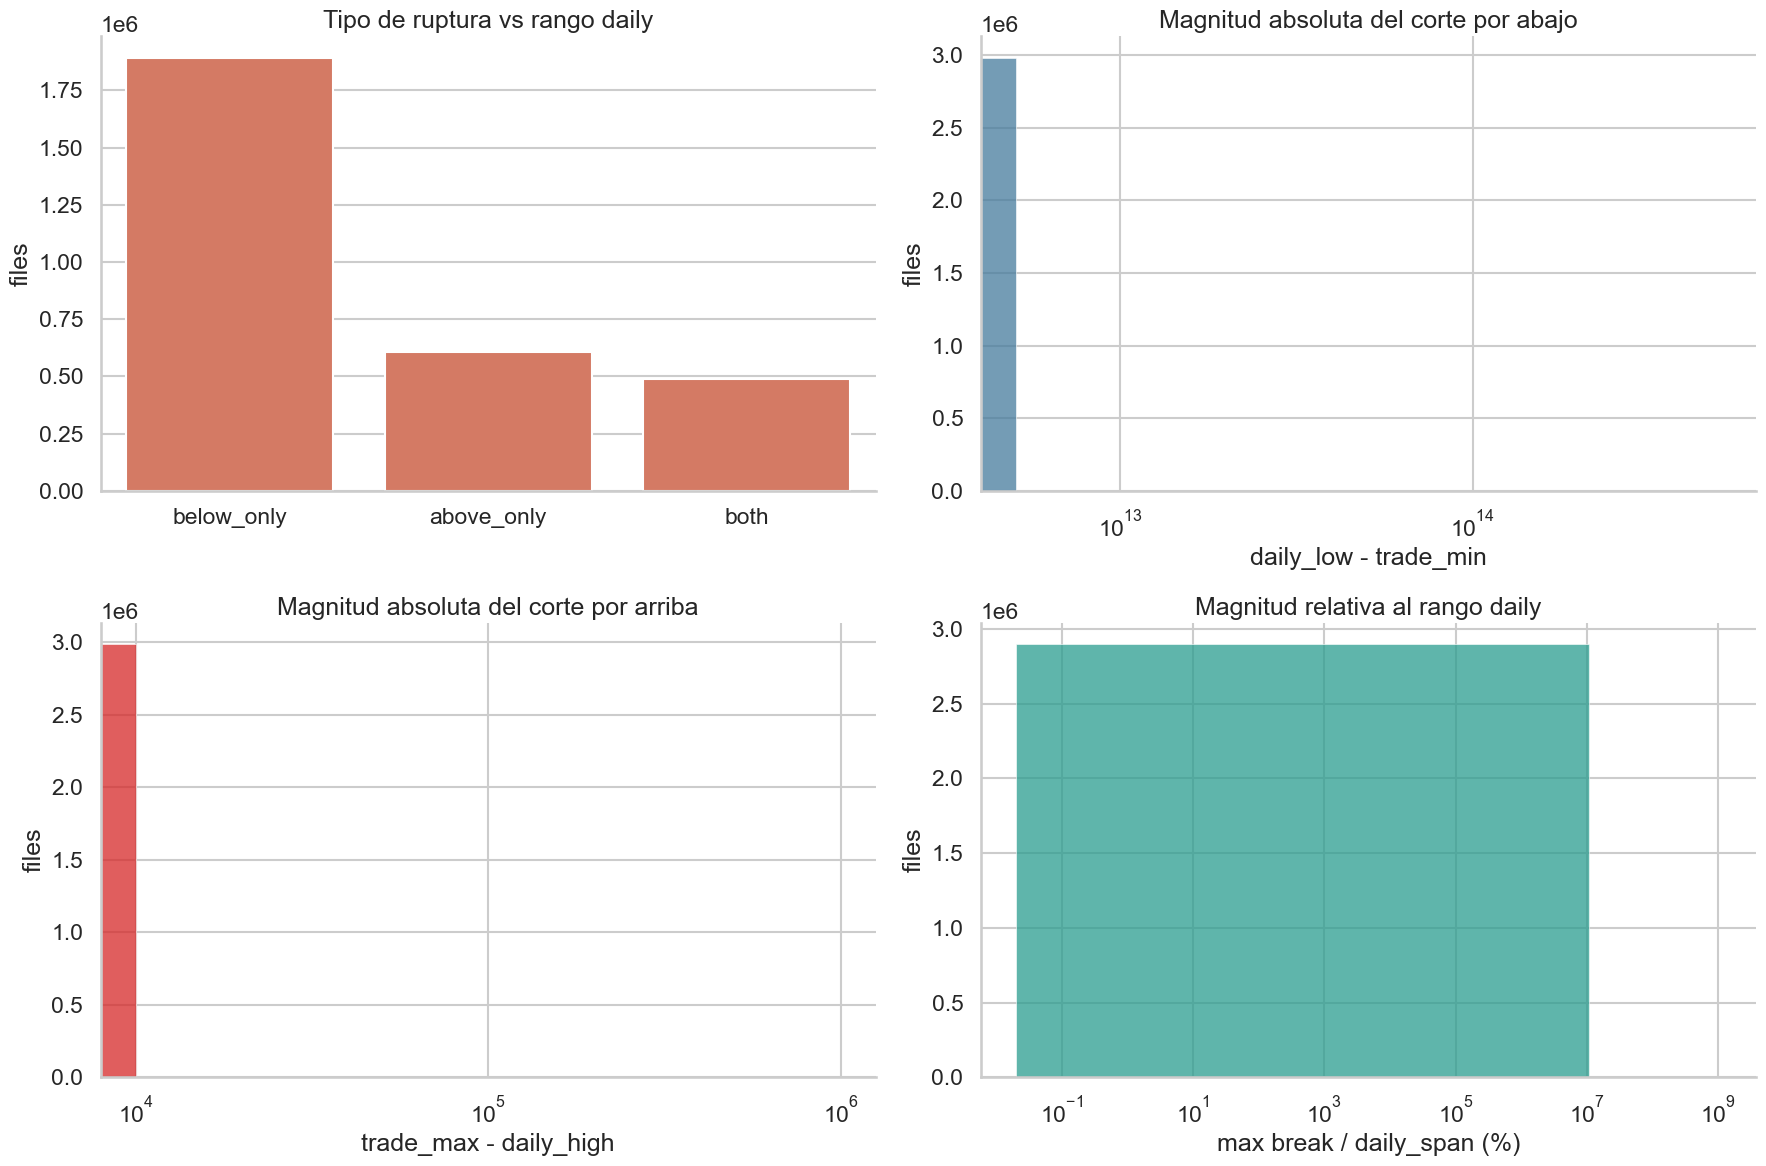

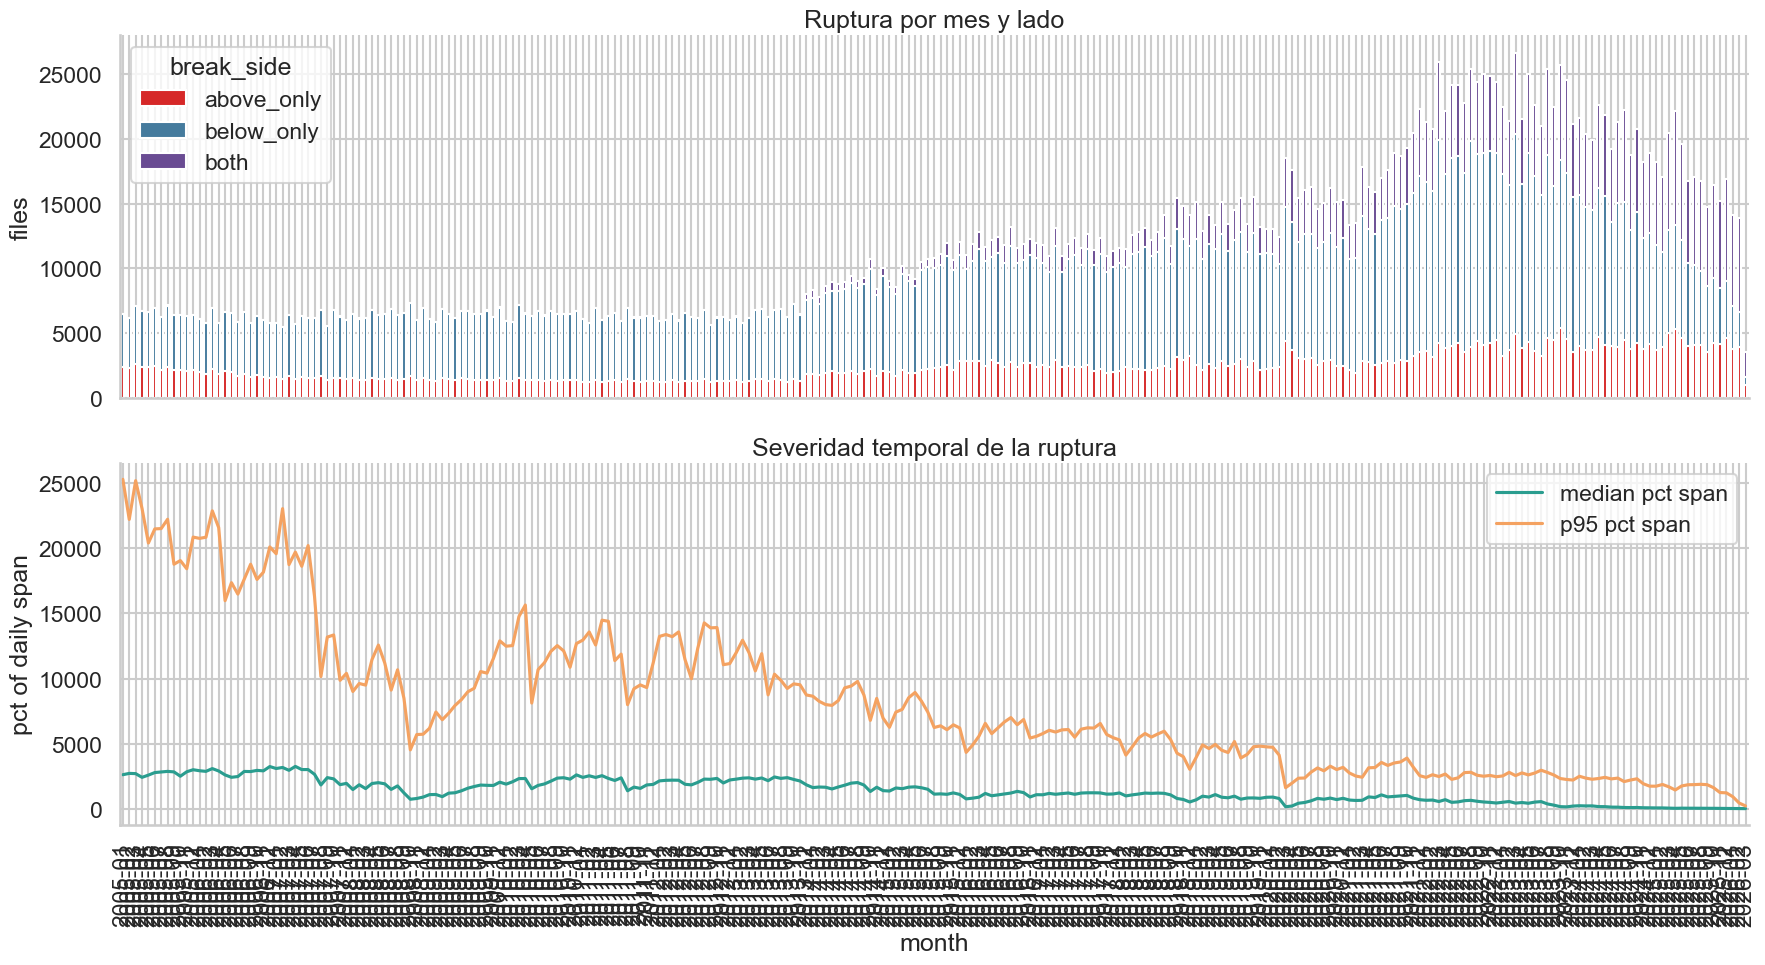

,ticker,date,severity,break_side,break_below_abs,break_above_abs,break_below_pct_span,break_above_pct_span,break_abs_max,break_pct_span_max,m.trade_vwap,m.vw,m.possible_price_scale_factor_vs_daily,m.possible_price_scale_factor_vs_1m,m.trade_volume_vs_daily_ratio,m.trade_volume_vs_1m_ratio,file
0,BHRB,2022-04-01,HARD_FAIL,above_only,0.000000e+00,2169.3750,0.000000e+00,1.084688e+09,2.169375e+03,1.084688e+09,2224.996000,5.562490e+01,40.000000,40.000000,0.025000,0.025000,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\BHRB\year=2022\month=04\day=2022-04-01\market.parquet
1,GLOW,2011-12-19,HARD_FAIL,above_only,0.000000e+00,199997.6699,0.000000e+00,9.950133e+08,1.999977e+05,9.950133e+08,1317.822590,2.309000e+00,570.733040,571.123087,1.134383,1.134383,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\GLOW\year=2011\month=12\day=2011-12-19\market.parquet
2,BHRB,2022-01-24,HARD_FAIL,above_only,0.000000e+00,2131.3597,0.000000e+00,7.104532e+08,2.131360e+03,7.104532e+08,2186.000526,5.465000e+01,40.000010,39.999966,0.025000,0.025000,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\BHRB\year=2022\month=01\day=2022-01-24\market.parquet
3,OHRP,2013-06-19,HARD_FAIL,above_only,0.000000e+00,199991.9400,0.000000e+00,4.999798e+08,1.999919e+05,4.999798e+08,4684.864021,8.034200e+00,583.115185,583.330363,1.088008,1.088008,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\OHRP\year=2013\month=06\day=2013-06-19\market.parquet
4,BHRB,2022-07-15,HARD_FAIL,above_only,0.000000e+00,1998.7695,0.000000e+00,3.997539e+08,1.998769e+03,3.997539e+08,2050.018571,5.125050e+01,39.999972,40.000050,0.025000,0.025000,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\BHRB\year=2022\month=07\day=2022-07-15\market.parquet
5,BWL.A,2009-03-26,HARD_FAIL,above_only,0.000000e+00,198990.1500,0.000000e+00,3.310984e+08,1.989901e+05,3.310984e+08,66339.878325,9.817500e+00,6757.308717,6753.623448,1.500000,1.500000,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\BWL.A\year=2009\month=03\day=2009-03-26\market.parquet
6,BLVD,2014-06-04,HARD_FAIL,above_only,0.000000e+00,199989.9600,0.000000e+00,2.856999e+08,1.999900e+05,2.856999e+08,44378.278392,1.000210e+01,4436.896091,4432.803995,1.285103,1.502500,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\BLVD\year=2014\month=06\day=2014-06-04\market.parquet
7,AAMC,2013-10-11,HARD_FAIL,above_only,0.000000e+00,253.2353,0.000000e+00,2.532353e+08,2.532353e+02,2.532353e+08,614.680020,3.617647e+02,1.699116,1.699116,0.601056,0.601056,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AAMC\year=2013\month=10\day=2013-10-11\market.parquet
8,TOF,2010-06-21,HARD_FAIL,above_only,0.000000e+00,999996.6000,0.000000e+00,2.325573e+08,9.999966e+05,2.325573e+08,9253.482707,3.248400e+00,2848.627850,2855.532852,1.018849,1.018849,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\TOF\year=2010\month=06\day=2010-06-21\market.parquet
9,AUD,2013-04-05,HARD_FAIL,below_only,2.996567e+03,0.0000,9.988557e+07,0.000000e+00,2.996567e+03,9.988557e+07,103.329954,3.099899e+03,0.033333,0.033333,30.000000,30.000002,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\AUD\year=2013\month=04\day=2013-04-05\market.parquet


In [8]:
SCRIPT_46 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/46_cd_break_overview.py")
mod46 = runpy.run_path(str(SCRIPT_46))

daily_break_full = load_break_cache()
break_summary_cd = load_cache("break_summary_cd")
top_breaks = load_cache("top_breaks_cd")

display_table(break_summary_cd.T, "break_summary_cd")
mod46["display_daily_break_summary"](daily_break_full)
mod46["plot_daily_break_overview"](daily_break_full)
mod46["plot_daily_break_temporal"](daily_break_full)
display_table(top_breaks, "top_breaks")


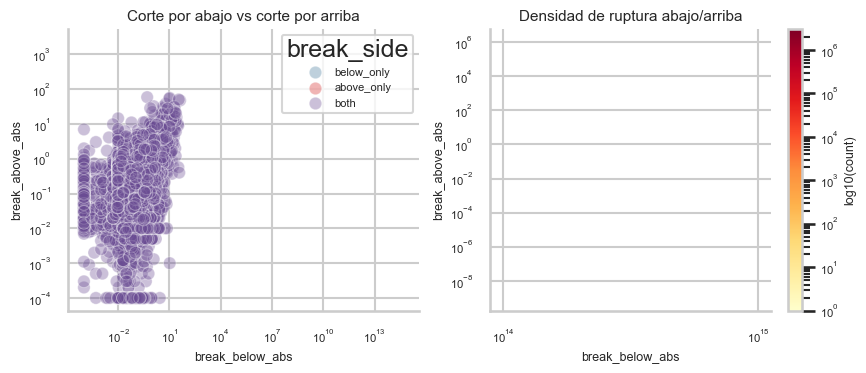

,ticker,date,break_side,break_below_abs,break_above_abs,break_below_pct_span,break_above_pct_span,break_pct_span_max
1701661,BHRB,2022-04-01,above_only,0.000000e+00,2169.3750,0.000000e+00,1.084688e+09,1.084688e+09
1471238,GLOW,2011-12-19,above_only,0.000000e+00,199997.6699,0.000000e+00,9.950133e+08,9.950133e+08
2737465,BHRB,2022-01-24,above_only,0.000000e+00,2131.3597,0.000000e+00,7.104532e+08,7.104532e+08
2931445,OHRP,2013-06-19,above_only,0.000000e+00,199991.9400,0.000000e+00,4.999798e+08,4.999798e+08
2737468,BHRB,2022-07-15,above_only,0.000000e+00,1998.7695,0.000000e+00,3.997539e+08,3.997539e+08
926392,BWL.A,2009-03-26,above_only,0.000000e+00,198990.1500,0.000000e+00,3.310984e+08,3.310984e+08
924077,BLVD,2014-06-04,above_only,0.000000e+00,199989.9600,0.000000e+00,2.856999e+08,2.856999e+08
2335545,AAMC,2013-10-11,above_only,0.000000e+00,253.2353,0.000000e+00,2.532353e+08,2.532353e+08
893977,TOF,2010-06-21,above_only,0.000000e+00,999996.6000,0.000000e+00,2.325573e+08,2.325573e+08
2604356,AUD,2013-04-05,below_only,2.996567e+03,0.0000,9.988557e+07,0.000000e+00,9.988557e+07


,0
files,2.983713e+06
p50_below_abs,7.140000e+00
p90_below_abs,8.928000e+02
p95_below_abs,5.757120e+03
p99_below_abs,1.901529e+06
p50_above_abs,0.000000e+00
p90_above_abs,1.085000e+00
p95_above_abs,6.480000e+00
p99_above_abs,2.588750e+01
p50_pct_span,9.457284e+02


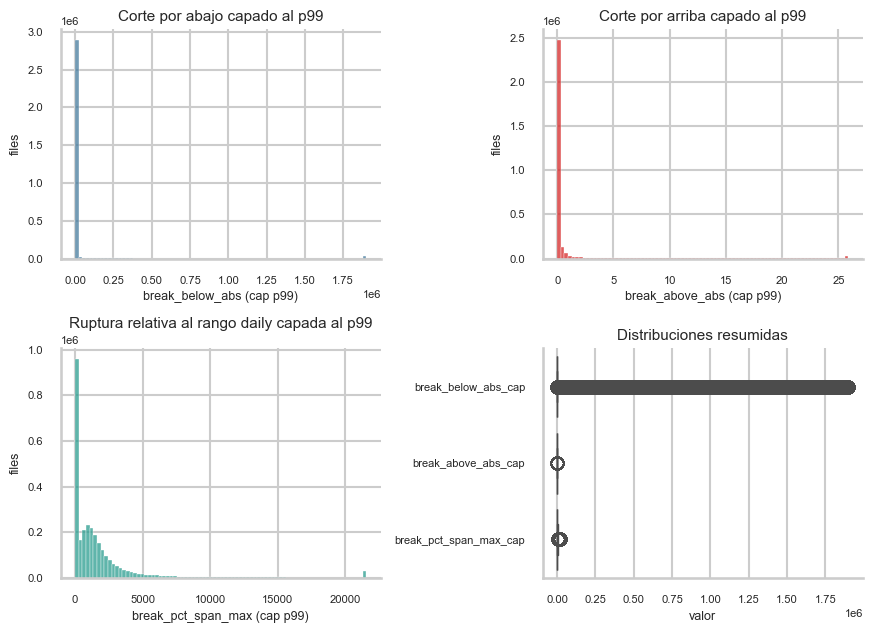

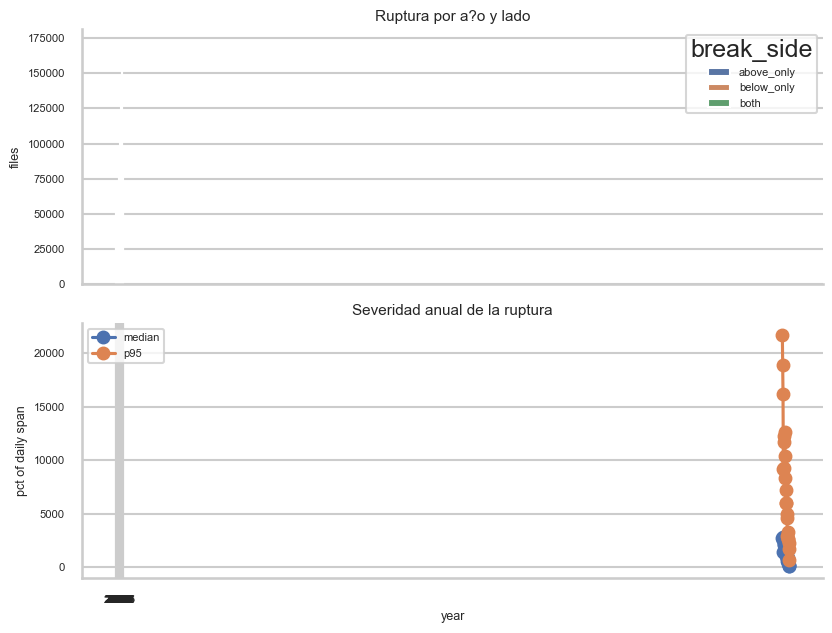

In [9]:
SCRIPT_52 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/52_cd_break_followup.py")
mod52 = runpy.run_path(str(SCRIPT_52))

daily_break_full = load_break_cache()
plot_df = mod52["build_break_side_scatter_view"](daily_break_full)
plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

with plt.rc_context(plot_rc):
    mod52["plot_break_side_scatter"](plot_df)
display_table(mod52["build_break_extreme_view"](plot_df, top_n=get_table_rows("break_extreme_view", 30)), "break_extreme_view")

viz_df, summary_breaks = mod52["build_break_visual_summary"](daily_break_full)
display_table(summary_breaks.T, "summary_breaks")
with plt.rc_context(plot_rc):
    mod52["plot_break_visual_summary"](viz_df)

tmp, year_side, year_mag = mod52["build_year_break_views"](daily_break_full)
with plt.rc_context(plot_rc):
    mod52["plot_year_break_views"](year_side, year_mag)

release_df("daily_break_full", "plot_df", "viz_df", "summary_breaks", "tmp", "year_side", "year_mag")


1. La mayoría de casos están muy cerca de 0 en magnitud absoluta.
     Eso significa que muchos trade_price_outside_daily_range rompen el rango daily por poco, no por barbaridades extremas.
  2. Pero la magnitud relativa al rango diario es enorme en muchos casos.
     Esto pasa porque el daily_span = high - low es muy pequeño en muchos nombres/días. Entonces una ruptura absoluta pequeña puede
     ser un % del rango gigantesco.
  3. El p99 sigue dominado por outliers.
     En el gráfico capado al p99, todavía ves:
      - break_below_abs_cap con una cola brutal
      - break_pct_span_max_cap con valores altísimos
        O sea: incluso quitando el 1% más extremo, la cola sigue siendo muy pesada.
  4. El lado “por abajo” parece especialmente dominante en masa.
     Eso ya lo sugería el reparto anterior y aquí sigue cuadrando.

  Lo que sigue mal visualmente:

  - El eje absoluto de break_below_abs_cap sigue contaminado por outliers gigantes.
  - El gráfico anual superior prácticamente no se ve porque sns.barplot no es la mejor opción para eso en esta escala.
  - El gráfico anual inferior sufre porque el eje X está desalineado o con pocos años efectivos visibles.

  La lectura técnica correcta es:

  - no tienes solo unos pocos accidentes extremos
  - tienes una masa muy grande de rupturas pequeñas en absoluto pero significativas respecto al rango daily
  - además coexistiendo con una cola de outliers enormes

  La siguiente visualización correcta ya no debería ser histograma bruto, sino segmentación por bandas. Eso sí comunica.


  Esta celda s? responde preguntas ?tiles:

  - cu?ntos rompen por c?ntimos
  - cu?ntos rompen por m?s de 1 d?lar
  - cu?ntos son >100% del rango diario
  - cu?ntos son >1000%


,bucket,files
0,<=0.01,21035
1,0.01-0.05,161631
2,0.05-0.10,141355
3,0.10-0.25,267667
4,0.25-0.50,214918
5,0.50-1,164488
6,1-5,286373
7,>5,1726246


,bucket,files
0,<=1%,95
1,1-5%,3154
2,5-10%,20707
3,10-25%,166683
4,25-50%,277698
5,50-100%,275382
6,100-500%,352687
7,500-1000%,398972
8,>1000%,1400355
9,NaN,87980


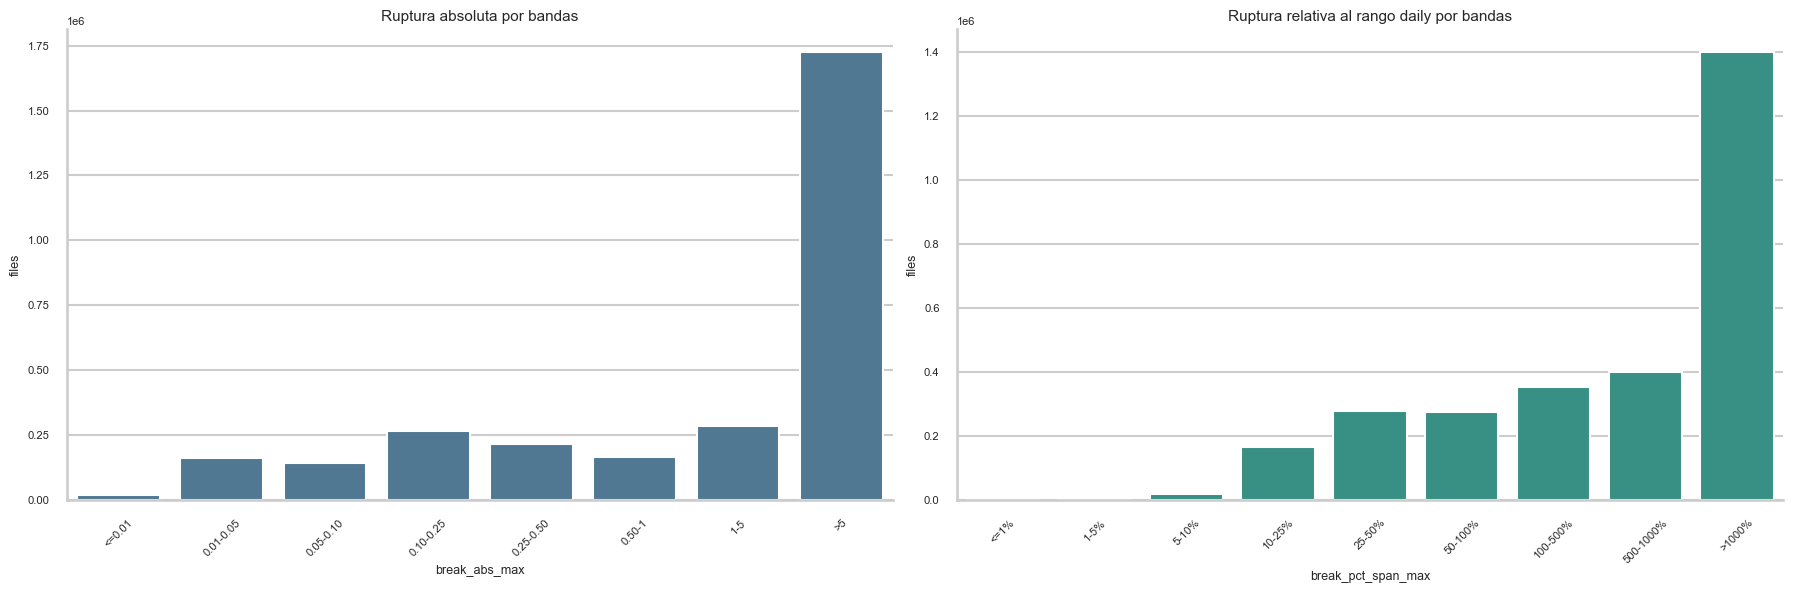

**cache:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\root_cause_exports\notebook_cd_cache\band_df_cd.parquet`

In [10]:
SCRIPT_47 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/47_cd_break_bands.py")
mod47 = runpy.run_path(str(SCRIPT_47))

band_df = load_band_cache()
abs_bucket_counts = load_cache("abs_bucket_counts_cd")
pct_bucket_counts = load_cache("pct_bucket_counts_cd")

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

display_table(abs_bucket_counts, "abs_bucket_counts")
display_table(pct_bucket_counts, "pct_bucket_counts")
with plt.rc_context(plot_rc):
    mod47["plot_band_counts"](abs_bucket_counts, pct_bucket_counts)

display(Markdown(f"**cache:** `{CACHE_DIR_CD / 'band_df_cd.parquet'}`"))
release_df("band_df")


celda cruzando bandas con break_side, para ver si:

  - las rupturas peque?as suelen ser por abajo
  - las monstruosas se concentran por arriba
  - o si both es el patr?n de los casos m?s sucios


,abs_break_bucket,break_side,files
0,<=0.01,above_only,10110
1,<=0.01,below_only,7695
2,<=0.01,both,3230
3,0.01-0.05,above_only,74796
4,0.01-0.05,below_only,43422
5,0.01-0.05,both,43413
6,0.05-0.10,above_only,57397
7,0.05-0.10,below_only,33396
8,0.05-0.10,both,50562
9,0.10-0.25,above_only,92656


,pct_break_bucket,break_side,files
0,<=1%,below_only,86
1,<=1%,both,9
2,1-5%,above_only,757
3,1-5%,below_only,1783
4,1-5%,both,614
5,5-10%,above_only,7427
6,5-10%,below_only,7804
7,5-10%,both,5476
8,10-25%,above_only,65343
9,10-25%,below_only,44705


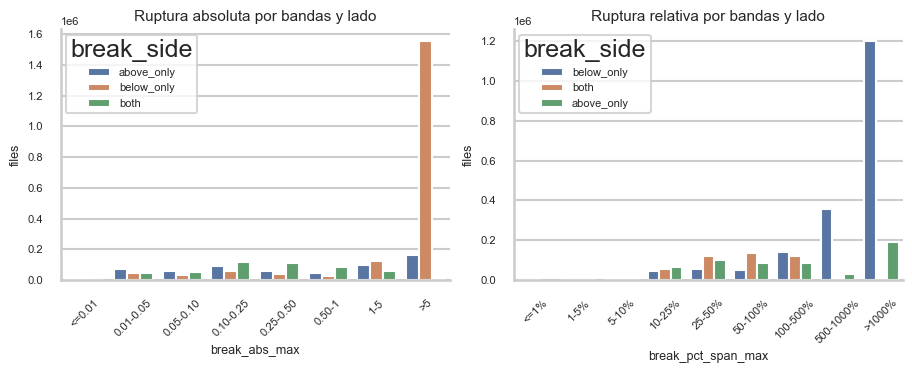

,abs_break_bucket,break_side,files,pct_in_bucket
0,<=0.01,above_only,10110,48.062753
1,<=0.01,below_only,7695,36.581887
2,<=0.01,both,3230,15.355360
3,0.01-0.05,above_only,74796,46.275776
4,0.01-0.05,below_only,43422,26.864896
5,0.01-0.05,both,43413,26.859328
6,0.05-0.10,above_only,57397,40.604860
7,0.05-0.10,below_only,33396,23.625623
8,0.05-0.10,both,50562,35.769516
9,0.10-0.25,above_only,92656,34.616146


,pct_break_bucket,break_side,files,pct_in_bucket
0,<=1%,below_only,86,90.526316
1,<=1%,both,9,9.473684
2,1-5%,above_only,757,24.001268
3,1-5%,below_only,1783,56.531389
4,1-5%,both,614,19.467343
5,5-10%,above_only,7427,35.867098
6,5-10%,below_only,7804,37.687738
7,5-10%,both,5476,26.445163
8,10-25%,above_only,65343,39.201958
9,10-25%,below_only,44705,26.820372


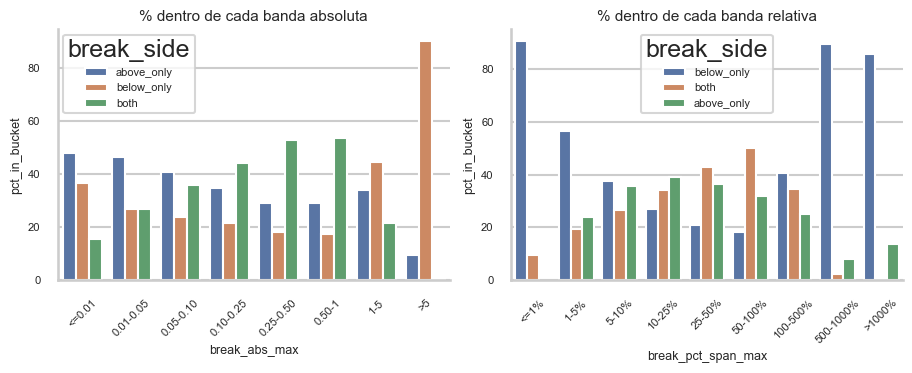

In [11]:
SCRIPT_53 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/53_cd_band_cross_analysis.py")
mod53 = runpy.run_path(str(SCRIPT_53))

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

cross_abs = load_cache("cross_abs_cd")
cross_pct = load_cache("cross_pct_cd")
display_table(cross_abs, "cross_abs")
display_table(cross_pct, "cross_pct")
with plt.rc_context(plot_rc):
    mod53["plot_cross_band_tables"](cross_abs, cross_pct)

cross_abs_pct = load_cache("cross_abs_pct_cd")
cross_pct_pct = load_cache("cross_pct_pct_cd")
display_table(cross_abs_pct.sort_values(["abs_break_bucket", "break_side"]), "cross_abs_pct")
display_table(cross_pct_pct.sort_values(["pct_break_bucket", "break_side"]), "cross_pct_pct")
with plt.rc_context(plot_rc):
    mod53["plot_cross_band_pct_tables"](cross_abs_pct, cross_pct_pct)

release_df("cross_abs", "cross_pct", "cross_abs_pct", "cross_pct_pct")


  Qu? dicen estos gr?ficos

  - En absoluto, la banda dominante es >5.
  - En relativo al rango daily, domina todav?a m?s >1000%.
  - Eso significa que no est?s viendo "micro-roturas" del rango diario. Est?s viendo roturas enormes.

  Lectura por lado

  - En las bandas absolutas peque?as (<=0.25 aprox.), above_only y both pesan bastante.
  - A medida que sube la ruptura absoluta, both gana en las bandas medias.
  - En la banda m?s extrema >5, domina casi por completo below_only.

  Eso ?ltimo es importante: los casos m?s monstruosos no son sim?tricos. Son sobre todo trades cayendo por debajo del daily low.

  Lectura relativa

  - En <=1%, casi todo es below_only, pero esa banda es marginal.
  - En 10-100% hay mezcla real entre below_only, above_only y both.
  - En 100-500% vuelve a dominar below_only.
  - En 500-1000% y >1000%, el dominio de below_only es casi total.

  Conclusi?n operativa:

  - El problema estructural del full no es "ruido peque?o alrededor del rango".
  - El problema dominante es una ruptura muy severa, mayoritariamente por abajo, y muchas veces descomunal respecto al rango daily.
  - Eso encaja bastante m?s con:
      - desalineaci?n fuerte de referencia/escala
      - corporate actions mal reflejadas
      - o inconsistencia grave entre trades y daily
        que con simples outliers de mercado.

  Qu? me llevo como hip?tesis principal
  trade_price_outside_daily_range en full parece tener dos poblaciones:

  - una intermedia, mixta, donde hay above_only, below_only y both
  - una extrema, muy dominante, donde casi todo es below_only

  Eso sugiere que no hay una sola causa. Hay al menos:

  - un bloque de desalineaci?n grave por abajo
  - y otro bloque m?s mixto de roturas menos extremas

  Siguiente celda ?til
  La correcta ahora es cruzar estas bandas con tres se?ales:

  - trade_price_outside_1m_range
  - possible_corporate_action_scale_mismatch_vs_daily / vs_1m
  - off_session_trades_present

  Eso te separa:

  - casos confirmados por 1m
  - casos de escala/corporate action
  - casos raros de sesi?n


   Esta celda te va a decir si las bandas extremas:

  - est?n confirmadas por 1m
  - huelen a scale mismatch
  - vienen con off-session
  - o vienen sucias por duplicados

  La lectura buena ser?:

  - si sube mucho pct_1m_break, el caso es m?s real/consistente contra 1m
  - si sube mucho pct_scale_warn, huele a problema de escala/corporate action
  - si sube mucho pct_off_session, puede haber problema de sesi?n/horario
  - si sube mucho pct_dup_warn, puede haber contaminaci?n por duplicados


,abs_break_bucket,files,pct_1m_break,pct_scale_warn,pct_off_session,pct_dup_warn
0,<=0.01,21035,84.906109,0.009508,34.271452,39.995246
1,0.01-0.05,161631,89.464274,0.004331,34.525555,56.771906
2,0.05-0.10,141355,94.693502,0.000000,33.708040,58.832019
3,0.10-0.25,267667,97.151685,0.000374,33.163969,59.671906
4,0.25-0.50,214918,98.175583,0.000000,33.795680,61.012572
5,0.50-1,164488,98.474053,0.002432,34.158115,62.016682
6,1-5,286373,98.826356,0.091489,33.036983,59.030705
7,>5,1726246,99.403387,0.031977,33.306898,61.313973


,pct_break_bucket,files,pct_1m_break,pct_scale_warn,pct_off_session,pct_dup_warn
0,<=1%,95,85.263158,1.052632,29.473684,60.000000
1,1-5%,3154,79.105897,0.000000,38.617628,75.142676
2,5-10%,20707,84.995412,0.000000,37.909886,73.960496
3,10-25%,166683,90.991883,0.001800,36.576016,71.724171
4,25-50%,277698,95.625824,0.002881,35.396366,67.434407
5,50-100%,275382,98.199955,0.010894,34.454322,62.238636
6,100-500%,352687,99.422434,0.103208,34.543944,61.576695
7,500-1000%,398972,99.625788,0.060155,35.750378,68.335873
8,>1000%,1400355,99.453781,0.012211,32.313449,57.649596


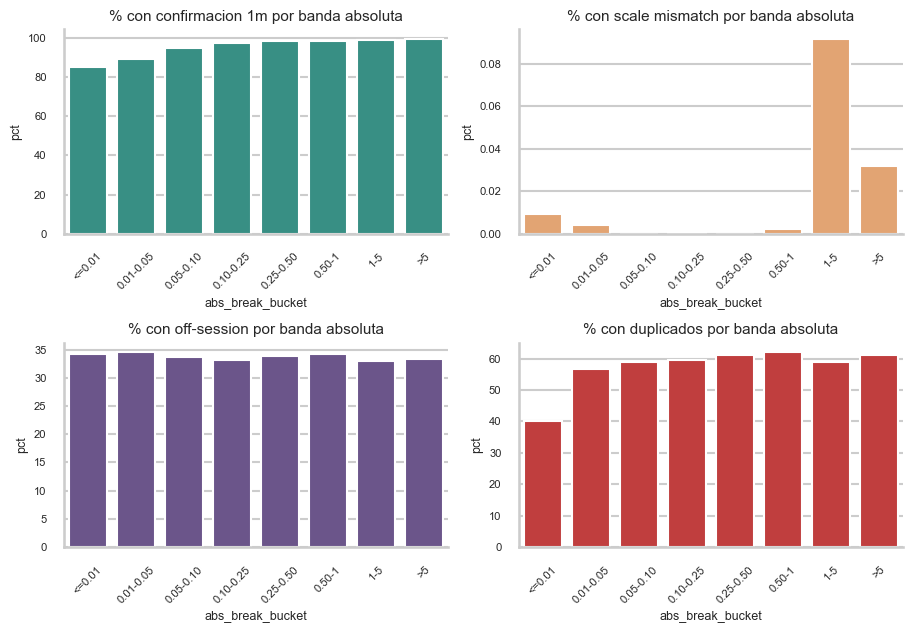

,break_side,files,pct_1m_break,pct_scale_warn,pct_off_session,pct_dup_warn,median_abs_break,p95_abs_break,median_pct_break,p95_pct_break
0,above_only,604899,95.230609,0.001157,32.297127,54.243436,0.54,25.395,137.500000,12632.158322
1,below_only,1891223,98.986846,0.043305,33.446717,61.460177,48.14,25199.300,1355.411987,5699.964165
2,both,487591,98.480489,0.000410,34.844778,64.235394,0.30,2.240,63.139932,416.666667


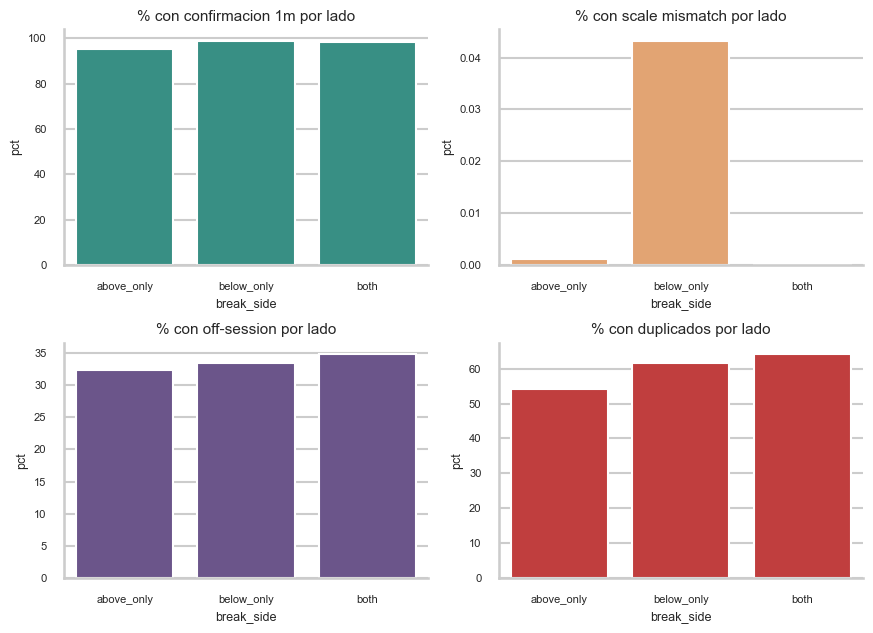

,break_side,files,pct_1m_break,pct_scale_warn,pct_off_session,pct_dup_warn,median_abs_break,p95_abs_break,median_pct_break,p95_pct_break
1,below_only,1891223,98.987,0.043,33.447,61.460,48.14,25199.300,1355.412,5699.964
0,above_only,604899,95.231,0.001,32.297,54.243,0.54,25.395,137.500,12632.158
2,both,487591,98.480,0.000,34.845,64.235,0.30,2.240,63.140,416.667


In [12]:
SCRIPT_54 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/54_cd_break_signal_explanation.py")
mod54 = runpy.run_path(str(SCRIPT_54))

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

band_df = load_band_cache()
explain_df = mod54["build_explain_df"](band_df)
abs_signal, pct_signal = mod54["build_abs_pct_signal_tables"](explain_df)
display_table(abs_signal, "abs_signal")
display_table(pct_signal, "pct_signal")
with plt.rc_context(plot_rc):
    mod54["plot_abs_signal"](abs_signal)

side_signal = mod54["build_side_signal"](explain_df)
display_table(side_signal, "side_signal")
with plt.rc_context(plot_rc):
    mod54["plot_side_signal"](side_signal)
side_signal_view = mod54["build_side_signal_view"](side_signal)
display_table(side_signal_view, "side_signal_view")

release_df("band_df", "explain_df", "abs_signal", "pct_signal", "side_signal", "side_signal_view")


## 6.b Validaci?n Positiva Del Hard Fail Dominante

Estas celdas no intentan forzar que todo `trade_price_outside_daily_range` est? bien. Bajan a raw files mediante muestra estratificada para separar tres bloques: una cohorte positiva defendible, una cohorte claramente estructural y una zona mixta que requiere m?s forense.


,abs_break_bucket,files,trade_vwap_inside_daily_pct,trade_vwap_near_1c_pct,trade_vwap_near_5c_pct
0,<=0.01,21035,87.093,100.000,100.000
1,0.01-0.05,161631,96.966,99.736,100.000
2,0.05-0.10,141355,95.395,98.427,99.827
3,0.10-0.25,267667,91.153,94.492,97.567
4,0.25-0.50,214918,87.994,90.155,93.373
5,0.50-1,164488,77.347,78.748,81.298
6,1-5,286373,27.481,27.788,28.500
7,>5,1726246,0.505,0.507,0.511


,abs_break_bucket,files,est_micro_1pct_share,est_micro_5pct_share,est_fully_outside_share
0,<=0.01,21035.0,42.723,64.085,0.000
1,0.01-0.05,161631.0,49.613,73.068,0.000
2,0.05-0.10,141355.0,38.982,63.760,0.000
3,0.10-0.25,267667.0,23.198,51.955,0.142
4,0.25-0.50,214918.0,21.948,54.921,1.936
5,0.50-1,164488.0,39.812,54.659,14.425
6,1-5,286373.0,3.346,13.033,73.621
7,>5,1726246.0,0.000,2.742,97.169


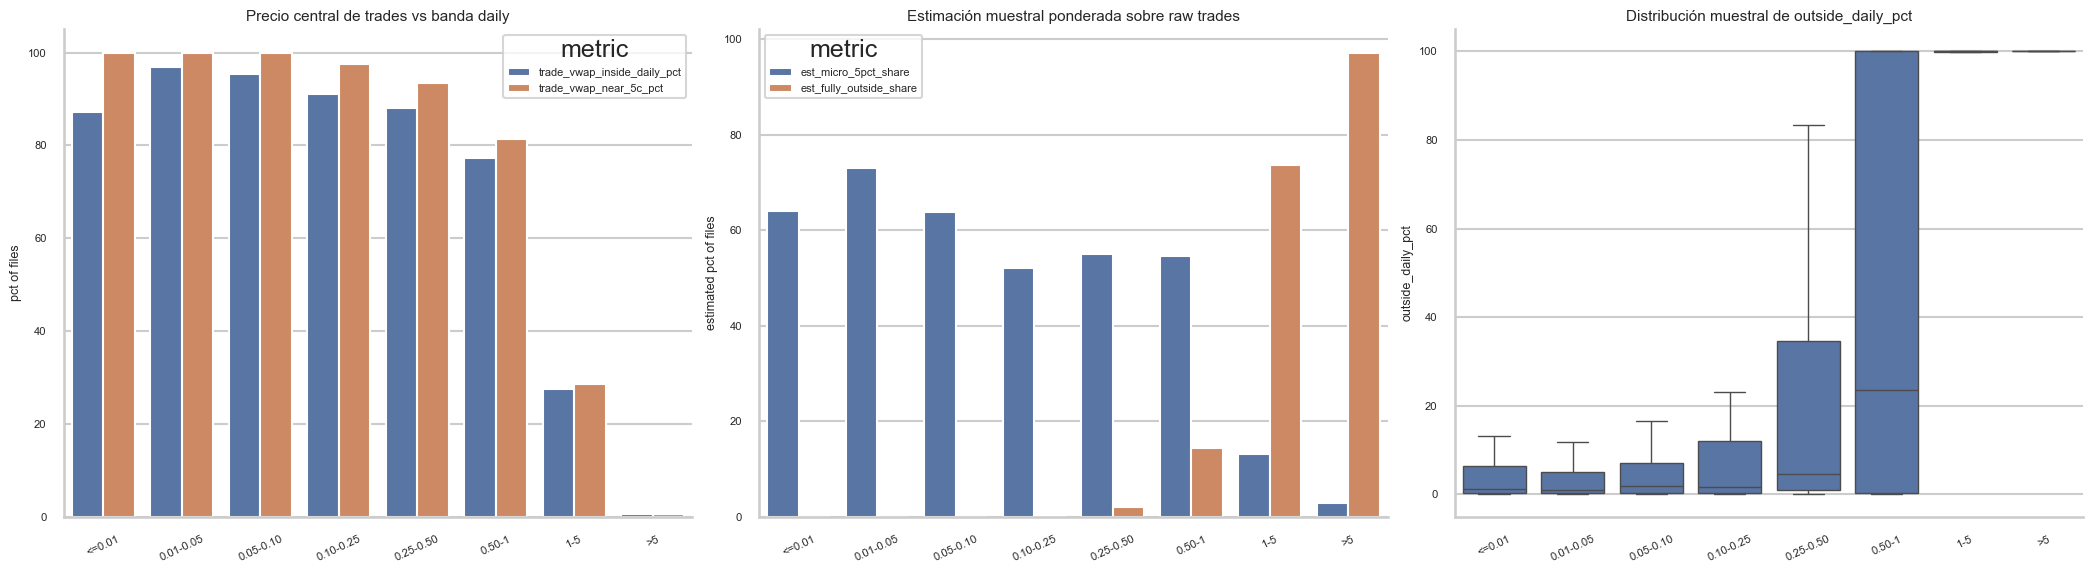

In [15]:
SCRIPT_56 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/56_cd_outside_daily_positive_split.py")
mod56 = runpy.run_path(str(SCRIPT_56))

tax_df = load_tax_cache()
alignment_by_bucket = mod56["build_alignment_by_bucket"](tax_df)
sample_df = mod56["build_stratified_outside_sample"](tax_df, sample_per_stratum=20, random_state=42)
weighted_bucket_summary = mod56["build_weighted_bucket_summary"](tax_df, sample_df)

display_table(alignment_by_bucket, "alignment_by_bucket")
display_table(weighted_bucket_summary, "weighted_bucket_summary")
with plt.rc_context(plot_rc):
    mod56["plot_positive_split_diagnostics"](alignment_by_bucket, weighted_bucket_summary, sample_df)


In [16]:
positive_split_summary = mod56["build_outside_sample_overall_summary"](tax_df, sample_df)
display_table(positive_split_summary, "positive_split_summary")
display(Markdown("""**Lectura operativa**

- El subconjunto con `break_abs_max <= 1` y `trade_vwap` dentro del rango daily es la cohorte positiva m?s defendible.
- La banda `>5` no se comporta como micro-outlier: en la muestra raw aparece casi siempre como ruptura plenamente fuera de rango.
- La conclusi?n ?til no es "todo est? bien", sino "qu? parte s? puede darse por positiva y qu? parte debe quedarse como residuo real".
"""))
release_df("tax_df", "alignment_by_bucket", "sample_df", "weighted_bucket_summary", "positive_split_summary")


,cohort,files,pct_of_issue,definition,sample_evidence
0,high_conf_positive_candidate,870222,29.166,break_abs_max <= 1 and trade_vwap inside daily,"in raw sample: 72.6% <=5% outside trades, 0% fully outside"
1,clearly_structural_break,1726246,57.856,break_abs_max > 5,weighted sample estimate: 97.2% fully outside
2,mixed_review_zone,387245,12.979,everything between both cohorts,needs narrower forensic split
3,weighted_sample_all_micro_5pct,2983713,21.898,estimated share with <=5% trades outside daily,weighted by taxonomy x abs bucket
4,weighted_sample_all_fully_outside,2983713,64.231,estimated share with ~100% trades outside daily,weighted by taxonomy x abs bucket


**Lectura operativa**

- El subconjunto con `break_abs_max <= 1` y `trade_vwap` dentro del rango daily es la cohorte positiva m?s defendible.
- La banda `>5` no se comporta como micro-outlier: en la muestra raw aparece casi siempre como ruptura plenamente fuera de rango.
- La conclusi?n ?til no es "todo est? bien", sino "qu? parte s? puede darse por positiva y qu? parte debe quedarse como residuo real".


 Nota importante:

  - aqu? he definido dup_heavy como duplicate_excess_ratio_pct >= 1.0
  - si quieres m?s estricto, s?belo a >= 5.0
  - si quieres m?s sensible, b?jalo a >= 0.5

  La lectura buena ser?:

  - si domina confirmed_by_1m_and_not_scale, el problema parece real contra referencias
  - si domina confirmed_by_1m_and_dup_heavy, el problema est? muy mezclado con duplicados
  - si pesa mucho not_confirmed_by_1m, entonces daily est? acusando cosas que 1m no confirma


,taxonomy,files,tickers,dates,pct_scale_warn,pct_dup_warn,pct_off_session,median_abs_break,p95_abs_break,median_pct_break,p95_pct_break
0,confirmed_by_1m_and_not_scale,1875771,4951,5325,0.000,50.661,33.367,5.332,3759.618,645.783,5096.438
1,confirmed_by_1m_and_dup_heavy,1052522,4787,5094,0.000,77.539,33.385,26.067,12956.400,1482.396,7544.697
2,not_confirmed_by_1m,55420,4066,5324,1.494,67.266,37.066,0.100,1963.730,31.667,2516.015


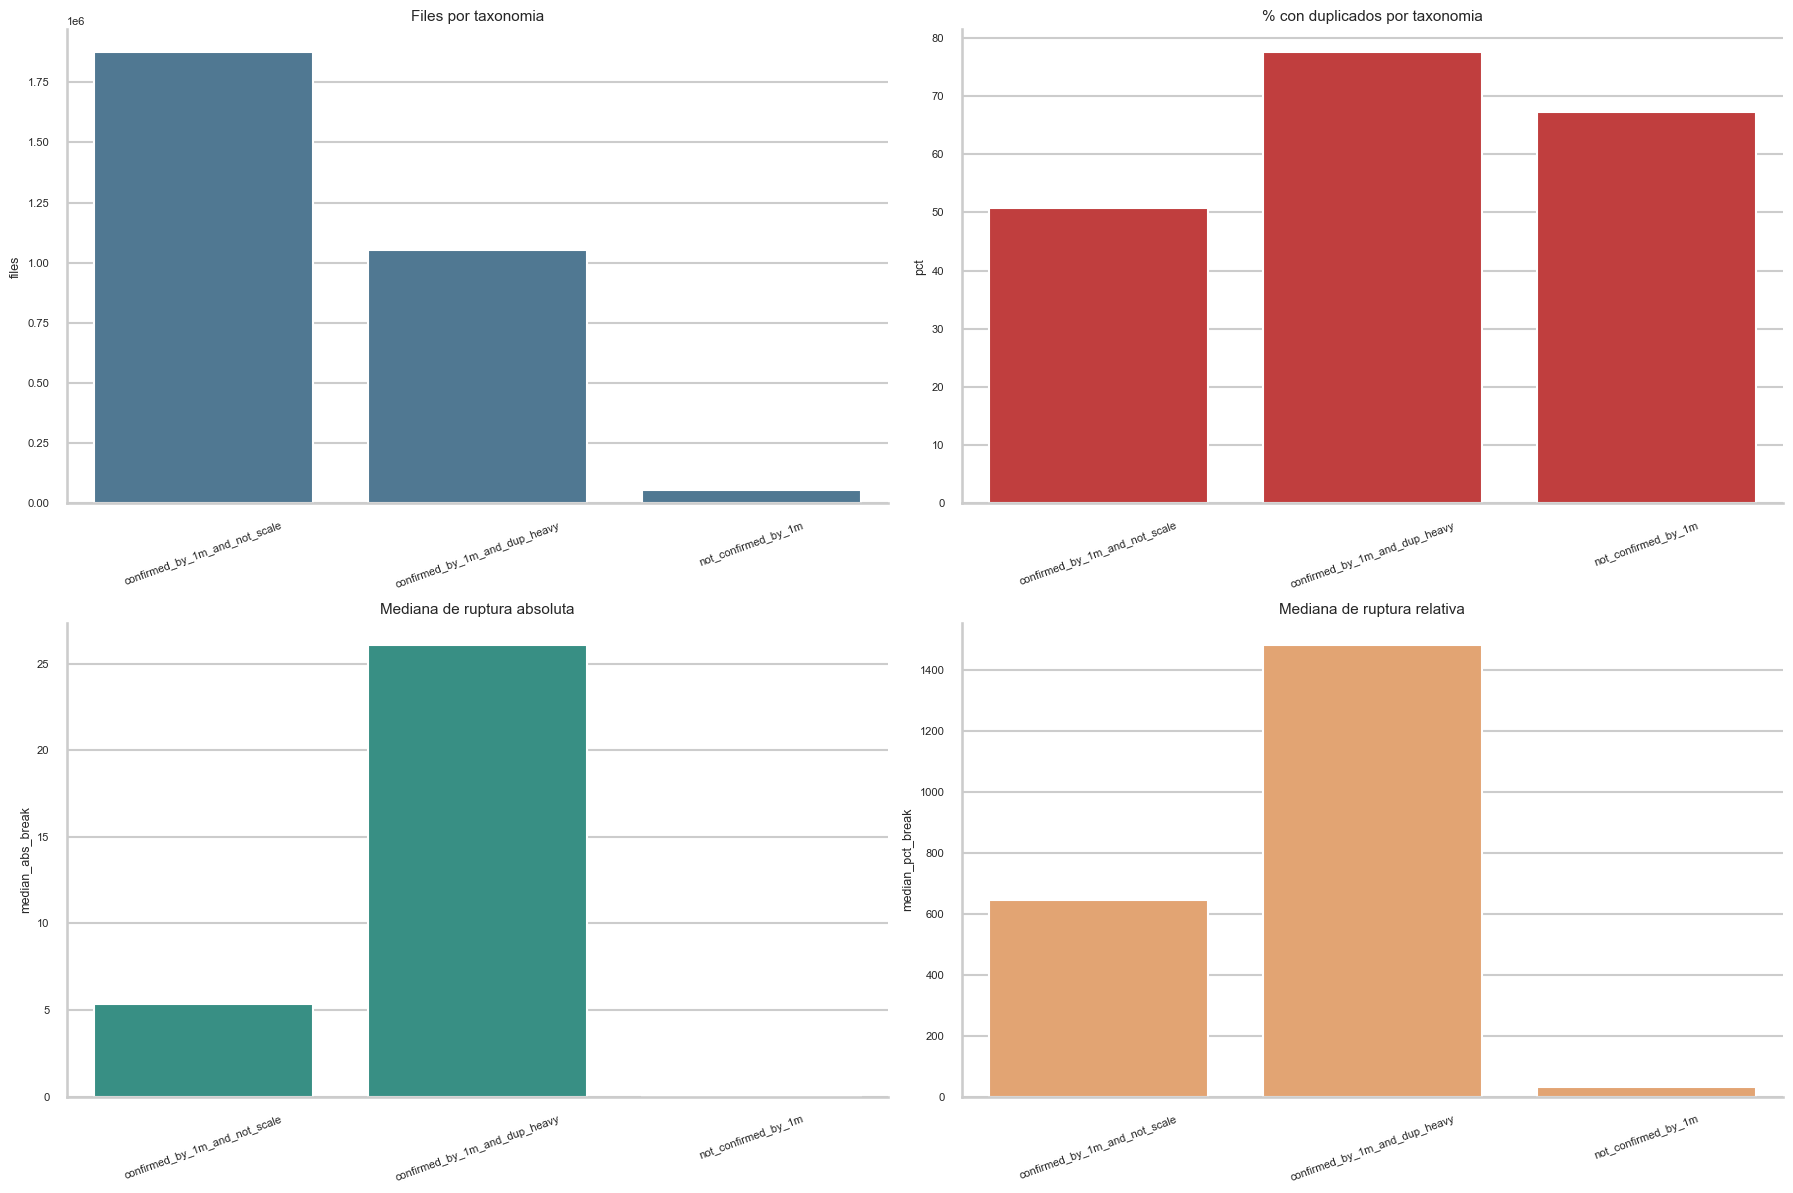

**cache:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\root_cause_exports\notebook_cd_cache\tax_df_cd.parquet`

In [17]:
SCRIPT_48 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/48_cd_taxonomy.py")
mod48 = runpy.run_path(str(SCRIPT_48))

tax_df = load_tax_cache()
taxonomy_summary = load_cache("taxonomy_summary_cd")

plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

display_table(taxonomy_summary, "taxonomy_summary")
with plt.rc_context(plot_rc):
    mod48["plot_taxonomy_summary"](taxonomy_summary)

display(Markdown(f"**cache:** `{CACHE_DIR_CD / 'tax_df_cd.parquet'}`"))
release_df("tax_df")


,taxonomy,break_side,files,median_abs_break,p95_abs_break,median_pct_break,p95_pct_break,pct_in_taxonomy
1,confirmed_by_1m_and_dup_heavy,below_only,772818,63.570,38554.470,1657.833,6525.000,73.425
0,confirmed_by_1m_and_dup_heavy,above_only,200996,2.940,29.025,1044.861,15640.117,19.097
2,confirmed_by_1m_and_dup_heavy,both,78708,0.240,2.000,77.648,766.667,7.478
4,confirmed_by_1m_and_not_scale,below_only,1099244,38.790,17983.760,1174.908,4948.133,58.602
5,confirmed_by_1m_and_not_scale,both,401474,0.314,2.200,61.111,368.414,21.403
3,confirmed_by_1m_and_not_scale,above_only,375053,0.350,24.290,86.000,11713.438,19.995
6,not_confirmed_by_1m,above_only,28850,0.050,3.913,26.582,508.922,52.057
7,not_confirmed_by_1m,below_only,19161,0.480,18744.460,81.250,3316.929,34.574
8,not_confirmed_by_1m,both,7409,0.430,9.956,31.765,155.994,13.369


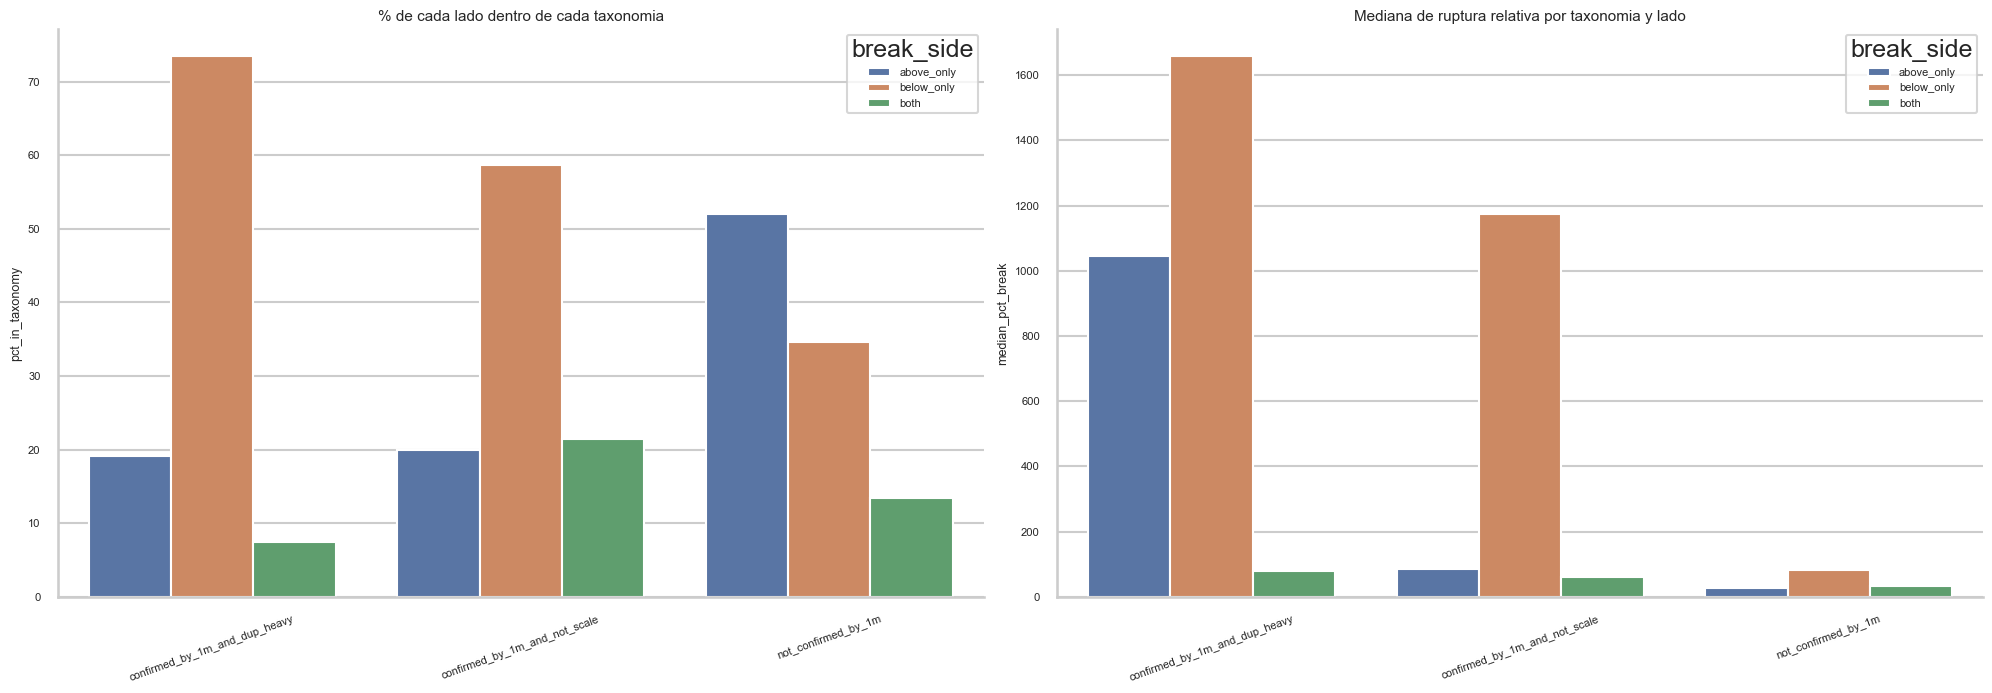

In [18]:
SCRIPT_49 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/49_cd_taxonomy_side.py")
mod49 = runpy.run_path(str(SCRIPT_49))

taxonomy_side = load_cache("taxonomy_side_cd")
plot_rc = {
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
}

with plt.rc_context(plot_rc):
    mod49["plot_taxonomy_side"](taxonomy_side)

release_df("taxonomy_side")


In [19]:
SCRIPT_55 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/55_cd_taxonomy_side_table.py")
mod55 = runpy.run_path(str(SCRIPT_55))

taxonomy_side = load_cache("taxonomy_side_cd")
taxonomy_side_view = mod55["build_taxonomy_side_view"](taxonomy_side)
display_table(taxonomy_side_view, "taxonomy_side_view")
release_df("taxonomy_side", "taxonomy_side_view")


,taxonomy,break_side,files,pct_in_taxonomy,median_abs_break,p95_abs_break,median_pct_break,p95_pct_break
1,confirmed_by_1m_and_dup_heavy,below_only,772818,73.425,63.570,38554.470,1657.833,6525.000
0,confirmed_by_1m_and_dup_heavy,above_only,200996,19.097,2.940,29.025,1044.861,15640.117
2,confirmed_by_1m_and_dup_heavy,both,78708,7.478,0.240,2.000,77.648,766.667
4,confirmed_by_1m_and_not_scale,below_only,1099244,58.602,38.790,17983.760,1174.908,4948.133
5,confirmed_by_1m_and_not_scale,both,401474,21.403,0.314,2.200,61.111,368.414
3,confirmed_by_1m_and_not_scale,above_only,375053,19.995,0.350,24.290,86.000,11713.438
6,not_confirmed_by_1m,above_only,28850,52.057,0.050,3.913,26.582,508.922
7,not_confirmed_by_1m,below_only,19161,34.574,0.480,18744.460,81.250,3316.929
8,not_confirmed_by_1m,both,7409,13.369,0.430,9.956,31.765,155.994


El full ya deja un patrón bastante claro:

- trade_price_outside_daily_range domina el residuo duro. Ya viste que no es marginal ni un outlier aislado.
- La confirmación por 1m es masiva, y además crece con la severidad. Eso descarta que el problema principal sea solo ruido contra
daily.
- scale mismatch pesa casi nada. Entonces la hipótesis “todo es corporate action / escala” no aguanta.
- Los duplicados sí pesan mucho, pero como contaminante transversal, no como explicación única.
- La morfología extrema se concentra sobre todo en below_only.
- La taxonomía deja dos bloques útiles:
    - confirmed_by_1m_and_not_scale: el bloque dominante, más limpio conceptualmente, y el que más huele a ruptura real contra
    referencia.
    - confirmed_by_1m_and_dup_heavy: segundo bloque, más severo y más sucio por duplicados.
- not_confirmed_by_1m existe, pero es minoritario y no explica el grueso del problema.

La lectura operativa final es: el core del problema no parece una falsa alarma de validación. Parece una ruptura real trades-vs-
referencias, con una subpoblación muy contaminada por duplicados.

Esta es la última celda que te recomiendo añadir. Te construye:

- ranking descendente de peores casos
- filtros por taxonomy y break_side
- widget para inspección visual
- overlay impecable de:
    - trades
    - velas 1m
    - referencias daily
- separado en:
    - premarket
    - regular market
    - after-hours


In [23]:
SCRIPT_50 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/50_cd_forensic_widget.py")
mod50 = runpy.run_path(str(SCRIPT_50), init_globals=globals())
tax_df = load_tax_cache().copy()

if "issues_list" not in tax_df.columns:
    tax_df["issues_list"] = [[] for _ in range(len(tax_df))]
if "warns_list" not in tax_df.columns:
    tax_df["warns_list"] = [[] for _ in range(len(tax_df))]

mod50["run_full_forensic_widget"](
    tax_df,
    initial_taxonomy="__ALL__",
    initial_side="__ALL__",
    initial_top_n=100,
    ranking_head=10,
)


## Top casos ordenados descendente

,rank,ticker,date,taxonomy,break_side,break_abs_max,break_pct_span_max,rank_score,m.trade_volume_vs_daily_ratio,m.trade_volume_vs_1m_ratio,m.duplicate_excess_ratio_pct,m.off_session_trade_pct
0,1,TOPS,2014-01-28,confirmed_by_1m_and_dup_heavy,below_only,2.751840e+12,1.820000e+06,19.394478,NaN,NaN,16.666667,NaN
1,2,TOPS,2012-07-16,confirmed_by_1m_and_dup_heavy,below_only,2.419200e+12,1.600000e+06,19.265645,NaN,NaN,16.666667,NaN
2,3,TOPS,2013-05-14,confirmed_by_1m_and_not_scale,below_only,2.313360e+12,1.530000e+06,19.220909,NaN,NaN,0.000000,NaN
3,4,TOPS,2013-11-01,confirmed_by_1m_and_dup_heavy,below_only,2.237760e+12,1.480000e+06,19.187683,NaN,NaN,33.333333,NaN
4,5,TOPS,2012-08-09,confirmed_by_1m_and_dup_heavy,below_only,2.041049e+12,1.349900e+06,19.095672,NaN,NaN,16.666667,NaN
5,6,TOPS,2012-08-23,confirmed_by_1m_and_dup_heavy,below_only,1.950329e+12,1.289900e+06,19.050206,NaN,NaN,25.000000,NaN
6,7,TOPS,2012-08-28,confirmed_by_1m_and_dup_heavy,below_only,1.874880e+12,1.240000e+06,19.010753,NaN,NaN,20.000000,NaN
7,8,TOPS,2012-11-20,confirmed_by_1m_and_dup_heavy,below_only,1.814400e+12,1.200000e+06,18.977963,NaN,NaN,15.384615,NaN
8,9,TOPS,2012-11-28,confirmed_by_1m_and_dup_heavy,below_only,1.693440e+12,1.120000e+06,18.908970,NaN,NaN,25.000000,NaN
9,10,TOPS,2013-01-25,confirmed_by_1m_and_not_scale,below_only,1.662898e+12,1.099800e+06,18.890770,NaN,NaN,0.000000,NaN


Output()

In [21]:
SCRIPT_51 = Path("C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/51_cd_final_bucket.py")
mod51 = runpy.run_path(str(SCRIPT_51))

EXPORT_DIR_CD = RUN_DIR_CD / "root_cause_exports"
final_df, final_summary, final_export_dir = mod51["run_cd_final_bucket"](
    tax_df,
    export_dir=EXPORT_DIR_CD,
    write_exports=True,
)

display_table(final_summary, "final_summary")
display(Markdown(f"**final_df rows:** {len(final_df):,}"))


,final_bucket,files,tickers,dates,median_abs_break,median_pct_break,pct_dup_warn,pct_off_session
2,likely_real_break_confirmed_by_1m,1875771,4951,5325,5.33200,645.783133,50.660662,0.0
0,likely_dup_heavy_break,1052522,4787,5094,26.06735,1482.395833,77.539092,0.0
1,likely_minor_unconfirmed_break,35742,3742,2872,0.04215,24.137931,82.840915,0.0
3,manual_review,18850,1665,5313,5.47380,1585.151084,37.108753,0.0
4,scale_suspect,828,257,628,7.38090,505.588235,81.521739,0.0


Exportado en: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\root_cause_exports`

,final_bucket,files,tickers,dates,median_abs_break,median_pct_break,pct_dup_warn,pct_off_session
2,likely_real_break_confirmed_by_1m,1875771,4951,5325,5.33200,645.783133,50.660662,0.0
0,likely_dup_heavy_break,1052522,4787,5094,26.06735,1482.395833,77.539092,0.0
1,likely_minor_unconfirmed_break,35742,3742,2872,0.04215,24.137931,82.840915,0.0
3,manual_review,18850,1665,5313,5.47380,1585.151084,37.108753,0.0
4,scale_suspect,828,257,628,7.38090,505.588235,81.521739,0.0


**final_df rows:** 2,983,713

In [22]:
tax_df = load_tax_cache()
case_index_cd = load_cache("case_index_cd")
display(Markdown(f"**taxonomy cache rows:** {len(tax_df):,}"))
display(Markdown(f"**case_index rows:** {len(case_index_cd):,}"))
release_df("tax_df", "case_index_cd")


**taxonomy cache rows:** 2,983,713

**case_index rows:** 2,560

## Lectura Ejecutiva Final

La auditor?a full `C + D` de `trades` apunta a un problema real, grande y estructural; no a ruido marginal de validaci?n.

### Se?ales principales

- El universo materializado contiene `9,632,124` filas.
- El reparto de severidad es muy agresivo:
  - `PASS`: `553,887` (`5.750%`)
  - `SOFT_FAIL`: `5,392,744` (`55.987%`)
  - `HARD_FAIL`: `3,685,493` (`38.263%`)
- El `HARD_FAIL` dominante es `trade_price_outside_daily_range` con `2,983,713` casos.
- La confirmaci?n contra `1m` es masiva: `trade_price_outside_1m_range` aparece en `5,094,621` filas.
- Los duplicados tambi?n pesan mucho: `duplicate_exact_trade_rows_present` aparece en `4,224,703` filas.
- `off_session_trades_present` aparece en `3,191,518` filas, as? que la microestructura fuera de sesi?n tambi?n es parte relevante del problema.

### Lectura t?cnica

La conclusi?n principal es que el bloque dominante no parece una falsa alarma de auditor?a.

La taxonom?a deja tres bloques, con un reparto muy informativo:

- `confirmed_by_1m_and_not_scale`: `1,875,771`
- `confirmed_by_1m_and_dup_heavy`: `1,052,522`
- `not_confirmed_by_1m`: `55,420`

Esto sugiere que:

- el n?cleo del problema est? efectivamente confirmado por `1m`
- la hip?tesis de `scale mismatch` no explica el grueso del residuo
- los duplicados son una contaminaci?n muy importante, pero no parecen ser la explicaci?n ?nica

### Morfolog?a del problema

- `below_only` domina claramente sobre `above_only`
- no hay solo unos pocos outliers extremos; hay una masa enorme de rupturas
- muchas rupturas son peque?as en absoluto pero muy grandes en porcentaje del `daily span`
- adem?s coexistiendo con una cola muy pesada de outliers extremos

En t?rminos operativos, esto apunta a dos capas superpuestas:

1. una ruptura estructural entre `trades` y referencias
2. una contaminaci?n fuerte por duplicados y por actividad fuera de sesi?n

### Conclusi?n operativa

El core del problema en `trades C + D` parece real, masivo y confirmado por `1m`.

Los duplicados y la actividad `off-session` agravan mucho el cuadro, pero la auditor?a no sugiere que todo el problema se reduzca a esos factores. La lectura m?s s?lida es que existe una subpoblaci?n dominante de breaks reales contra referencia, coexistiendo con otra subpoblaci?n muy sucia por duplicados.

### Prioridad recomendada

El siguiente an?lisis deber?a centrarse, en este orden, en:

1. `confirmed_by_1m_and_not_scale`
2. `confirmed_by_1m_and_dup_heavy`
3. `below_only`
4. top tickers con presi?n extrema de `HARD_FAIL`
5. casos con mayor `break_pct_span_max`
6. casos con fuerte presencia de `off_session_trades_present`



--- 


• He dejado el análisis nuevo ejecutado dentro de C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/
  trades/04_trades_full_C_D_audit.ipynb. Añadí un bloque nuevo 6.b con dos celdas de validación sobre raw files y lo soporté con C:/
  TSIS_Data/v1/backtest_SmallCaps/notebooks/00_data_certification/auditoria/trades/cell_code/56_cd_outside_daily_positive_split.py.

  El resultado importante es este: no se puede defender honestamente que casi todos los trade_price_outside_daily_range estén bien. Sí
  aparece una cohorte positiva defendible, pero no el universo entero. La celda final nueva deja este corte:

  - high_conf_positive_candidate: 870,222 filas, 29.166%
  - clearly_structural_break: 1,726,246 filas, 57.856%
  - mixed_review_zone: 387,245 filas, 12.979%

  La evidencia visual que ya queda en el notebook es:

  - En rupturas sub-dollar, el trade_vwap suele quedar dentro o muy pegado al daily.
  - En >5, eso colapsa: trade_vwap_inside_daily_pct = 0.505%.
  - La muestra raw ponderada estima solo 21.898% con <=5% de trades fuera de rango, frente a 64.231% que salen prácticamente 100% fuera de
    rango.
  - La banda >5 sale con 97.169% estimado como plenamente fuera.

  La conclusión útil ya no es “todo está bien”, sino “qué parte sí puede darse por positiva y qué parte queda como residuo real”. Si
  quieres, el siguiente paso es endurecer la cohorte positiva para convertirla en una taxonomía nueva dentro del notebook y del .md.